# Bike and Pedestrian Traffic

## Set Up

### Import Libraries

In [1]:
import warnings
import os
import sys
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import zipfile

import pprint
from IPython.display import display
import datetime

import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf , plot_accf_grid
import statsmodels.formula.api as smf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.api import VAR

from torchgen.packaged.autograd.gen_python_functions import PY_VARIABLE_METHOD_VARARGS
from tqdm import tqdm
from joblib import Parallel, delayed

import warnings

from scipy.interpolate import UnivariateSpline
from scipy.stats import poisson, chisquare
from scipy import stats

import requests

### Import Data

In [2]:
#Load Data

data = pd.read_csv('burke-gilman-trail-north-of-ne-70th-st-bike-and-ped-counter.csv')

In [3]:
#Define function for dataset statistics
def get_dataset_stats(df):
    print(f"Sample Size: {len(df)}")
    print(f"Number of Variables: {len(df.columns)}")
    print(f"Time Period: {df.index.min().date()} - {df.index.max().date()}")
    print(f"Missing Values: {df.isna().sum().sum()}")

In [4]:
#Create DataFrame
df = pd.DataFrame(data)
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace = True)

In [6]:
#Identify frequency of NA's by Year
print('NA in 2014')
print(df.loc['2014-1-1':'2015-1-1'].isna().sum())
print()

print('NA in 2015')
print(df.loc['2015-1-1':'2016-1-1'].isna().sum())
print()

print('NA in 2016')
print(df.loc['2016-1-1':'2017-1-1'].isna().sum())
print()

print('NA in 2017')
print(df.loc['2017-1-1':'2018-1-1'].isna().sum())
print()

print('NA in 2018')
print(df.loc['2018-1-1':'2019-1-1'].isna().sum())
print()

print('NA in 2019')
print(df.loc['2019-1-1':'2020-1-1'].isna().sum())
print()

print('NA in 2020')
print(df.loc['2020-1-1':'2021-1-1'].isna().sum())

NA in 2014
BGT North of NE 70th Total    2
Ped South                     2
Ped North                     2
Bike North                    2
Bike South                    2
dtype: int64

NA in 2015
BGT North of NE 70th Total    2
Ped South                     2
Ped North                     2
Bike North                    2
Bike South                    2
dtype: int64

NA in 2016
BGT North of NE 70th Total    1
Ped South                     1
Ped North                     1
Bike North                    1
Bike South                    1
dtype: int64

NA in 2017
BGT North of NE 70th Total    1
Ped South                     1
Ped North                     1
Bike North                    1
Bike South                    1
dtype: int64

NA in 2018
BGT North of NE 70th Total    2329
Ped South                     2329
Ped North                     2329
Bike North                    2329
Bike South                    2329
dtype: int64

NA in 2019
BGT North of NE 70th Total    0
Ped South        

In [6]:
#Investigate NA row details
df[df.isna()].head()

,BGT North of NE 70th Total,Ped South,Ped North,Bike North,Bike South
Date,,,,,
2014-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN
2014-01-01 01:00:00,NaN,NaN,NaN,NaN,NaN
2014-01-01 02:00:00,NaN,NaN,NaN,NaN,NaN
2014-01-01 03:00:00,NaN,NaN,NaN,NaN,NaN
2014-01-01 04:00:00,NaN,NaN,NaN,NaN,NaN


In [7]:
# Choose 6 month time period for forecasting. No NA's during this time period, so no need for imputation or interpolation.
df = df['2019-06-01':'2020-01-01']

In [8]:
#Create Total Columns for Pedestrians and Bikes respectively
df['Total Ped'] = df['Ped North'] + df['Ped South']
df['Total Bike'] = df['Bike North'] + df['Bike South']


### Examine Data Statistics

In [9]:
#Examine data types
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 5136 entries, 2019-06-01 00:00:00 to 2019-12-31 23:00:00
Data columns (total 7 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   BGT North of NE 70th Total  5136 non-null   float64
 1   Ped South                   5136 non-null   float64
 2   Ped North                   5136 non-null   float64
 3   Bike North                  5136 non-null   float64
 4   Bike South                  5136 non-null   float64
 5   Total Ped                   5136 non-null   float64
 6   Total Bike                  5136 non-null   float64
dtypes: float64(7)
memory usage: 321.0 KB


In [10]:
#Understand data statistics
df.describe()

,BGT North of NE 70th Total,Ped South,Ped North,Bike North,Bike South,Total Ped,Total Bike
count,5136.000000,5136.000000,5136.000000,5136.000000,5136.000000,5136.000000,5136.000000
mean,63.063863,8.507399,8.730335,21.625779,24.200350,17.237734,45.826129
std,77.118545,20.754360,15.342830,26.763935,36.114647,32.944599,58.429914
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.000000,0.000000,0.000000,1.000000,1.000000,0.000000,2.000000
50%,41.500000,6.000000,6.000000,11.000000,11.000000,13.000000,24.000000
75%,100.000000,14.000000,14.000000,34.000000,34.000000,28.000000,71.000000
max,1764.000000,1324.000000,782.000000,170.000000,961.000000,1752.000000,1039.000000


Based on the data statistics, there appears to be some very significant outliers in the dataset as indicated in the "max" row.

It is also interesting that the minimum values of the dataset are 0, this may prove to be a challenge since the variability will have a "floor" function associated with it.

There is significant variability in the dataset based on the ratio between the mean and standard deviations.

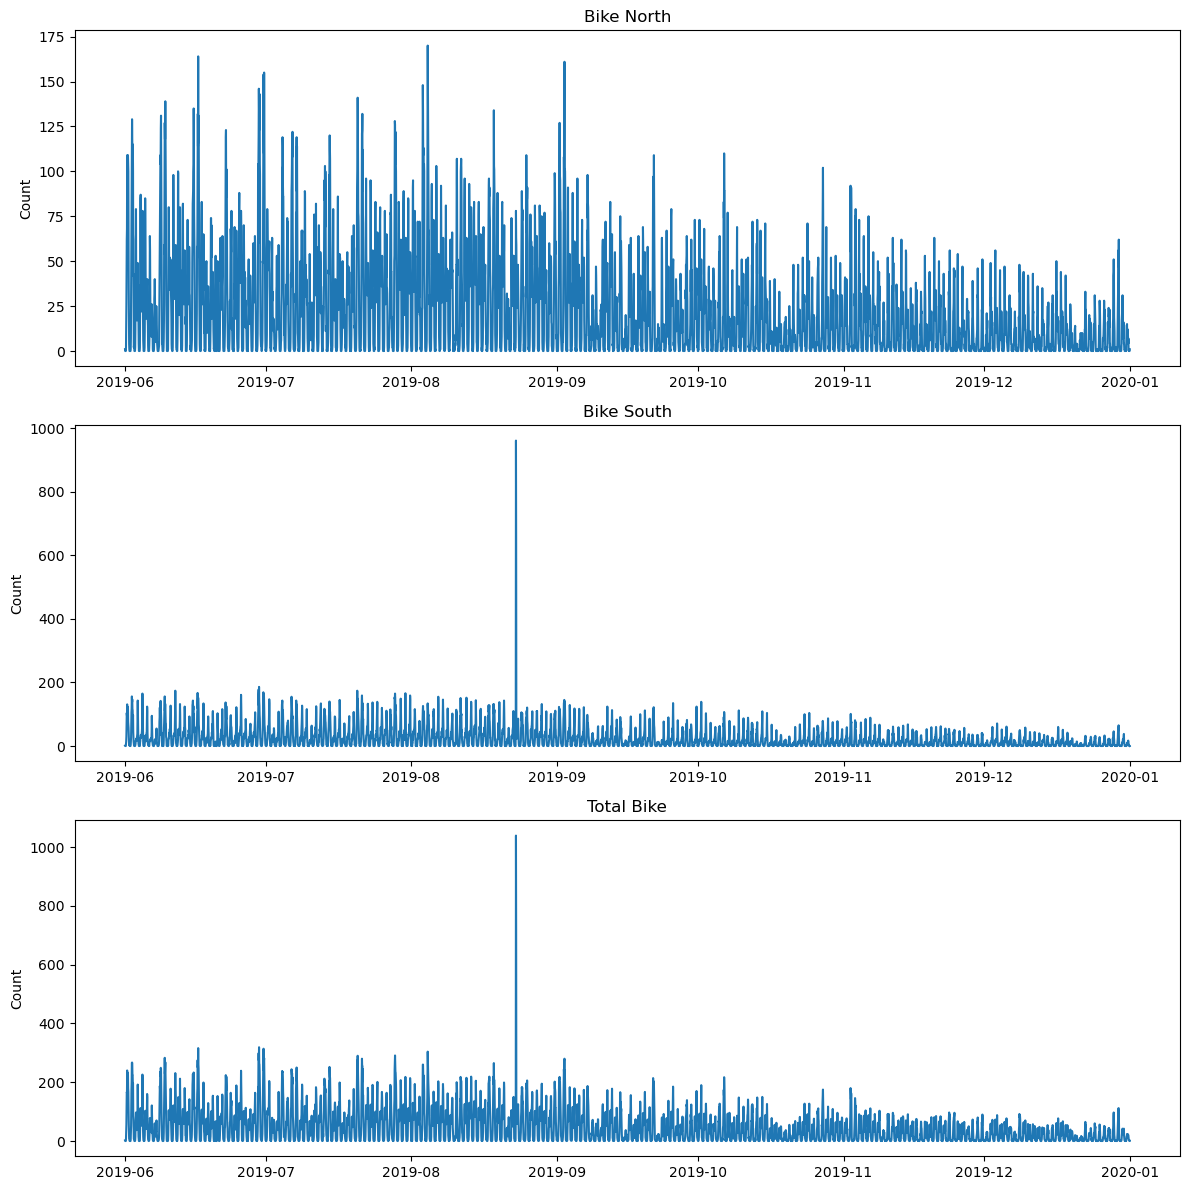

In [11]:
#Plot the data
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize = (12,12))

ax1.plot('Bike North', data = df)
ax1.set_title('Bike North')
ax1.set_ylabel('Count')

ax2.plot('Bike South', data = df)
ax2.set_title('Bike South')
ax2.set_ylabel('Count')

ax3.plot('Total Bike', data = df)
ax3.set_title('Total Bike')
ax3.set_ylabel('Count')

plt.tight_layout()
plt.show()

In [12]:
#Identify the date of the large outlier in the dataset for Bike South.
df[df['Total Bike'] == np.max(df['Total Bike'])]

,BGT North of NE 70th Total,Ped South,Ped North,Bike North,Bike South,Total Ped,Total Bike
Date,,,,,,,
2019-08-23 06:00:00,1085.0,38.0,8.0,78.0,961.0,46.0,1039.0


This will be removed and then imputed since it will prove to be an influential point otherwise, and is evidence of either an error in the dataset or a significant external event that affected that date specifically. If the dataset was annual, there would need to be more consideration before imputing it in case this is a recurring event.

In [13]:
#Imputation consisting of averaging the week previous and following the influential point for Bike South
df['last_week'] = df['Bike South'].shift(168)
df['next_week'] = df['Bike South'].shift(-168)

df['imputed'] = (df['last_week'] + df['next_week']) / 2

df.loc['2019-8-23', 'Bike South'] = df.loc['2019-8-23', 'imputed']


In [14]:
#Redefine Total Bike after the adjustment to Bike South
df['Total Bike'] = df['Bike North'] + df['Bike South']

df = df.drop(columns =['last_week','next_week','imputed'])

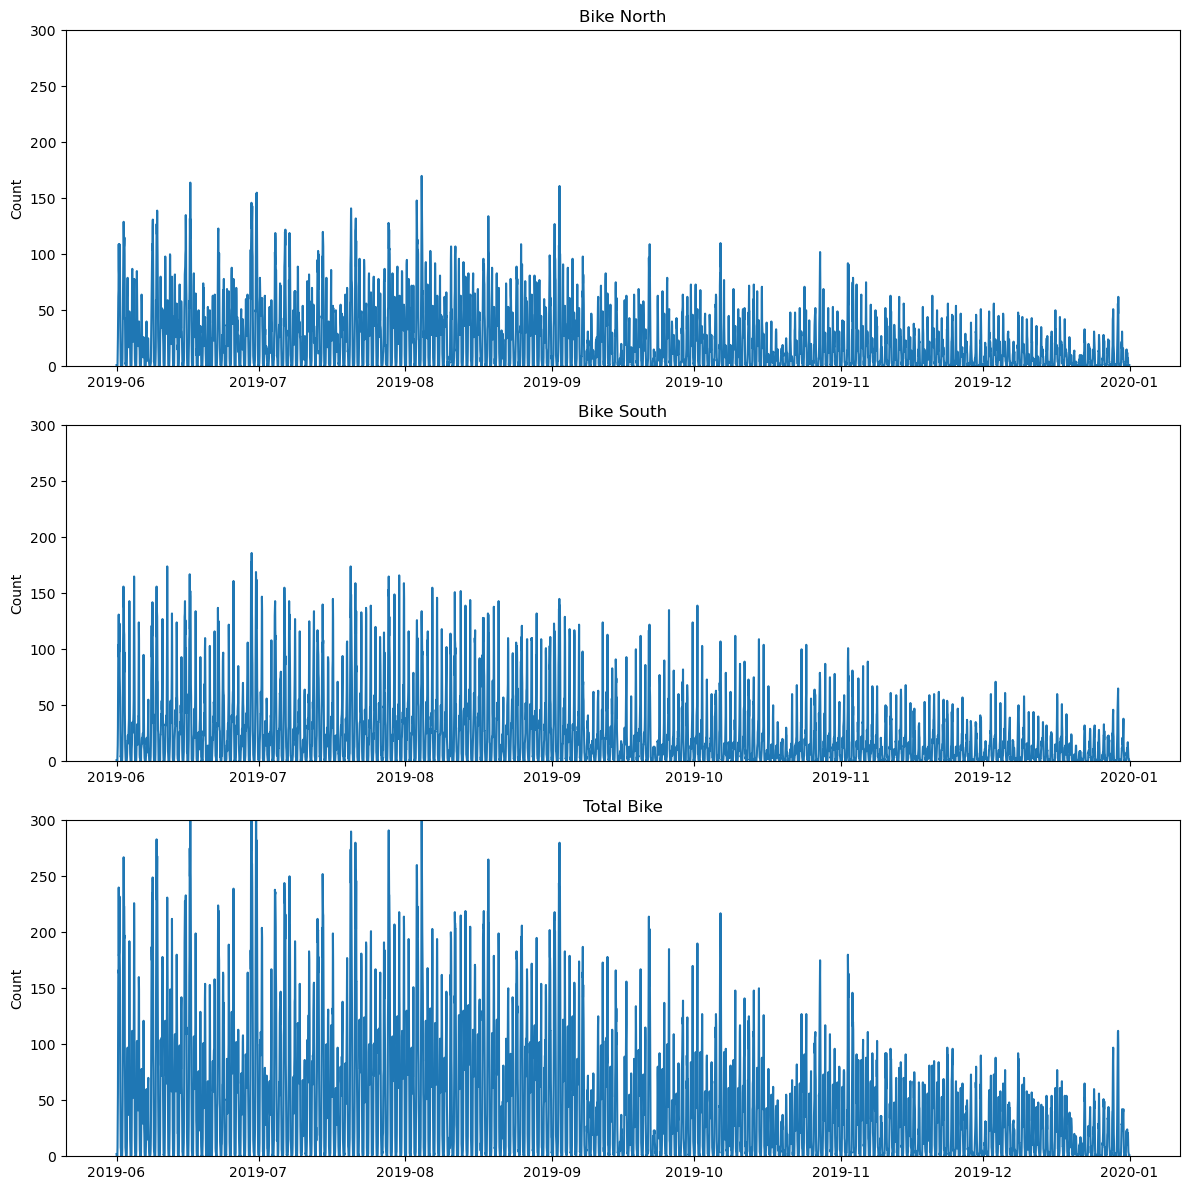

In [15]:
#Re-plot after imputation
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize = (12,12))

ax1.plot('Bike North', data = df)
ax1.set_title('Bike North')
ax1.set_ylabel('Count')
ax1.set_ylim((0,300))

ax2.plot('Bike South', data = df)
ax2.set_title('Bike South')
ax2.set_ylabel('Count')
ax2.set_ylim((0,300))

ax3.plot('Total Bike', data = df)
ax3.set_title('Total Bike')
ax3.set_ylabel('Count')
ax3.set_ylim((0,300))

plt.tight_layout()
plt.show()

In [16]:
get_dataset_stats(df)

Sample Size: 5136
Number of Variables: 7
Time Period: 2019-06-01 - 2019-12-31
Missing Values: 0


In [17]:
#Identify initial training and testing dataset. The goal is to predict the hourly Bike North rates for 1 full day in advance. Chose 12-28-2019 for no other basis than that it was my Birthday in 2019.
df_train_orig = df.loc[:'2019-12-27'].copy()
df_test= df.loc['2019-12-28'].copy()

## Data Exploration

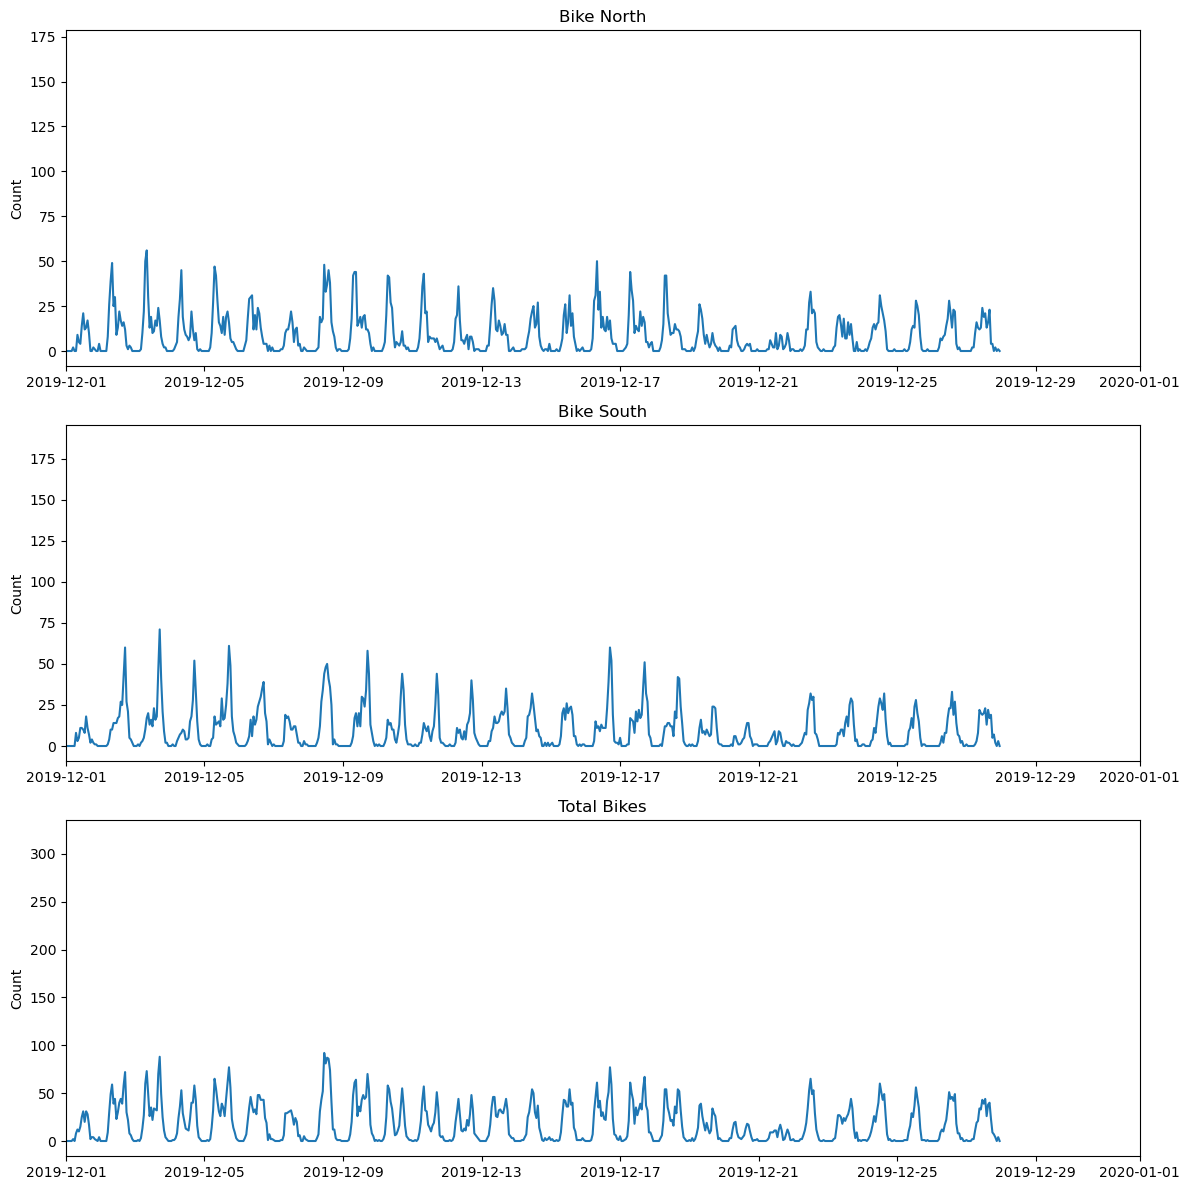

In [18]:
#Plot one month of data
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 12))

ax1.plot('Bike North', data=df_train_orig)
ax1.set_title('Bike North')
ax1.set_ylabel('Count')
ax1.set_xlim(datetime.datetime(2019, 12, 1), datetime.datetime(2020, 1, 1))

ax2.plot('Bike South', data=df_train_orig)
ax2.set_title('Bike South')
ax2.set_ylabel('Count')
ax2.set_xlim(datetime.datetime(2019, 12, 1), datetime.datetime(2020, 1, 1))

ax3.plot('Total Bike', data=df_train_orig)
ax3.set_title('Total Bikes')
ax3.set_ylabel('Count')
ax3.set_xlim(datetime.datetime(2019, 12, 1), datetime.datetime(2020, 1, 1))

plt.tight_layout()
plt.show()

There is significant seasonality in this dataset corresponding to Day/Night cycles. There is also some apparent bi-modality on most days, potentially corresponding to rush hour time periods.

There are also many  dates that appear dampened. 12-21-2019 had some significant precipitation that very likely deterred travel.

## Dedicated Analysis: Bike North

### SARIMA

In [19]:
#Given that this is arrival rate information, test whether it closely follows a Poisson Distribution.
num_freq = np.bincount(df_train_orig['Bike North'].astype(int))
distinct_values = np.arange(len(num_freq))

l = np.mean(df_train_orig)

poisson_dist = len(df_train_orig)*poisson.pmf(distinct_values,l)

poisson_dist[-1] = len(df_train_orig) - np.sum(poisson_dist[:-1])

chi2, pval = chisquare(num_freq, f_exp = poisson_dist, ddof=1)

print(pval)

0.0


The P-Value is near zero, so the null is firmly rejected and therefore statistically the data does not follow a Poisson Distribution closely.

In [20]:
#Box Cox Transformation
bike_north_transformed, optimal_l = stats.boxcox(df_train_orig['Bike North']+1)
print(optimal_l)

0.08341122560363673


Since the output of the Box Cox transformation is close to 0, I will proceed with utilizing the natural log transformation.

In [21]:
#Natural log transform
df_train = np.log(df_train_orig+1).copy()

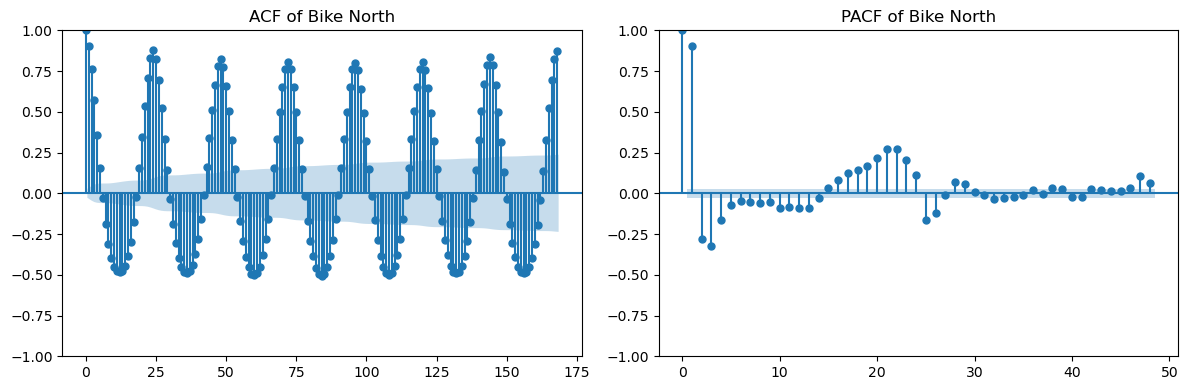

In [22]:
#Analyze ACF and PACF Plots
fig, (ax1,ax2) = plt.subplots(1 , 2, figsize=(12, 4))
plot_acf(df_train['Bike North'], lags = 24*7, ax = ax1, title = 'ACF of Bike North')
plot_pacf(df_train['Bike North'], lags = 24*2, ax = ax2, title = 'PACF of Bike North')
plt.tight_layout()
plt.show()

The ACF Plot displays that the data is firmly non stationary, with very strong 24 hour seasonality. There is also an apparent 168 (7 day) seasononality visible in the ACF plot. There is also strong negative correlation at each 12 hour interval.

The PACF plot displays significant direct positive autocorrelation at the first lag, and negative autocorrelation at the 2nd - 5th lags. There is also significant direct autocorrelation between lag hours ~18 - 26.

In [23]:
#Fit Spline Regression to extract macro trend
time_pts = np.arange(len(df_train['Bike North']))
time_norm = (time_pts - time_pts.min()) / time_pts.max()
spline_bike_north = UnivariateSpline(time_norm, df_train['Bike North'], s=len(df_train['Bike North'])*10)
spline_fit_bike_north = spline_bike_north(time_norm)
df_train['bike_north_fit_gam'] = spline_fit_bike_north
df_train['bike_north_gam_resid'] = df_train['Bike North'] - df_train['bike_north_fit_gam']

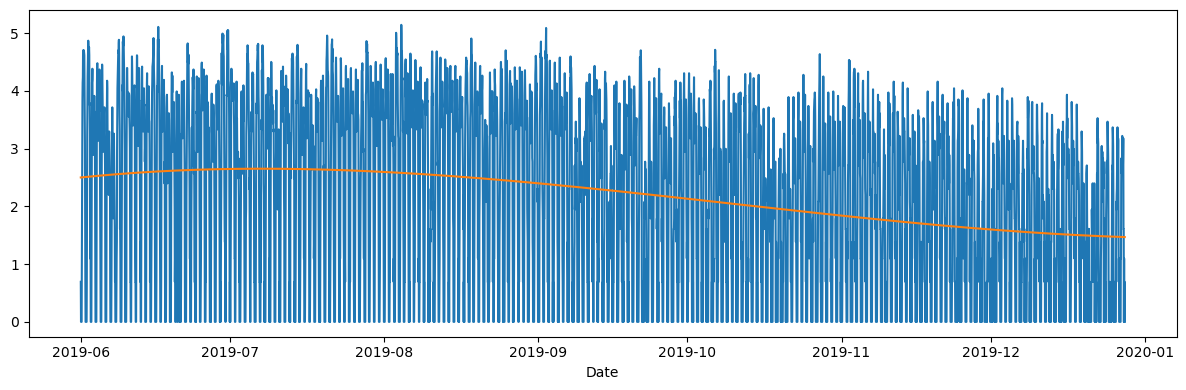

In [24]:
#Plot spline trend overlayed on training data
fig, ax = plt.subplots(figsize = (12,4))
plt.plot(df_train.index, df_train['Bike North'])
plt.plot(df_train.index, df_train['bike_north_fit_gam'])
plt.xlabel('Date')
plt.tight_layout()
plt.show()

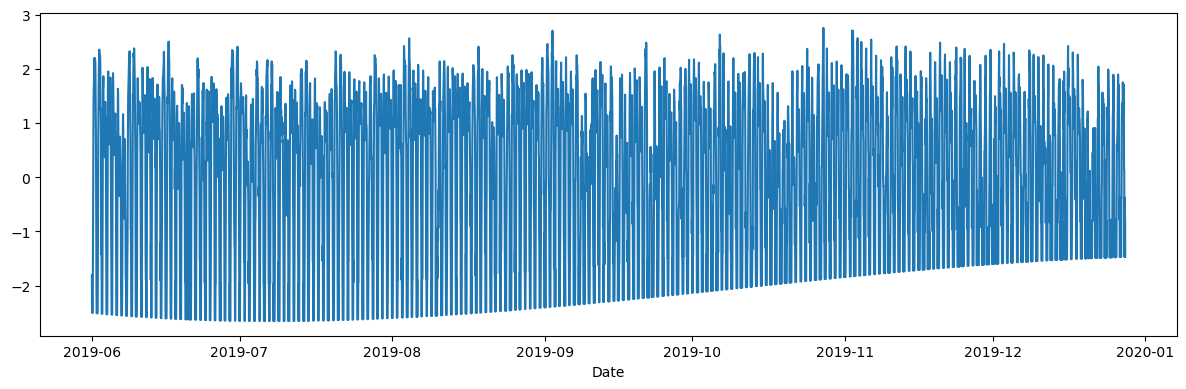

In [25]:
#Plot residuals from spline regression
plt.figure(1,(12,4))
plt.plot(df_train.index, df_train['bike_north_gam_resid'])
plt.xlabel('Date')
plt.tight_layout()
plt.show()

The heteroskedasticity appears to be resolved on the upper values of the dataset, however the zero values result in heteroskedasticity being left in the dataset towards the lower end of the dataset.

This is a limitation of the data that is being modeled. Modeling will continue, however this is expected to impact performance.

In [26]:
#Seasonality Modeling
week_hour = df_train.index.dayofweek*24 + df_train.index.hour

df_train['cos1'] = np.cos(2 * np.pi * (df_train.index.hour) / 12)
df_train['sin1'] = np.sin(2 * np.pi * (df_train.index.hour) / 12)
df_train['cos2'] = np.cos(2 * np.pi * (df_train.index.hour) / 24)
df_train['sin2'] = np.sin(2 * np.pi * (df_train.index.hour) / 24)
df_train['cos3'] = np.cos(2 * np.pi * (week_hour) / 168)
df_train['sin3'] = np.sin(2 * np.pi * (week_hour) / 168)

harmonic_gam_bike_north = smf.ols(formula='bike_north_gam_resid ~ cos1 + sin1 + cos2 + sin2 + cos3 + sin3', data=df_train).fit()
print(harmonic_gam_bike_north.summary())

df_train['bike_north_harmonic_gam_resid'] = harmonic_gam_bike_north.resid

                             OLS Regression Results                             
Dep. Variable:     bike_north_gam_resid   R-squared:                       0.776
Model:                              OLS   Adj. R-squared:                  0.776
Method:                   Least Squares   F-statistic:                     2909.
Date:                  Fri, 01 May 2026   Prob (F-statistic):               0.00
Time:                          20:46:59   Log-Likelihood:                -5497.6
No. Observations:                  5040   AIC:                         1.101e+04
Df Residuals:                      5033   BIC:                         1.105e+04
Df Model:                             6                                         
Covariance Type:              nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -7.459e-14      0.010

Utilizing 3 periods of seasonality: 12 hour, 24 hour, and 168 hour.

12 hour is utilized to attempt to capture differences in rush hour timing.
24 hour and 168 hour are utilized based on the information gathered from the ACF plot

All coefficients are significant.

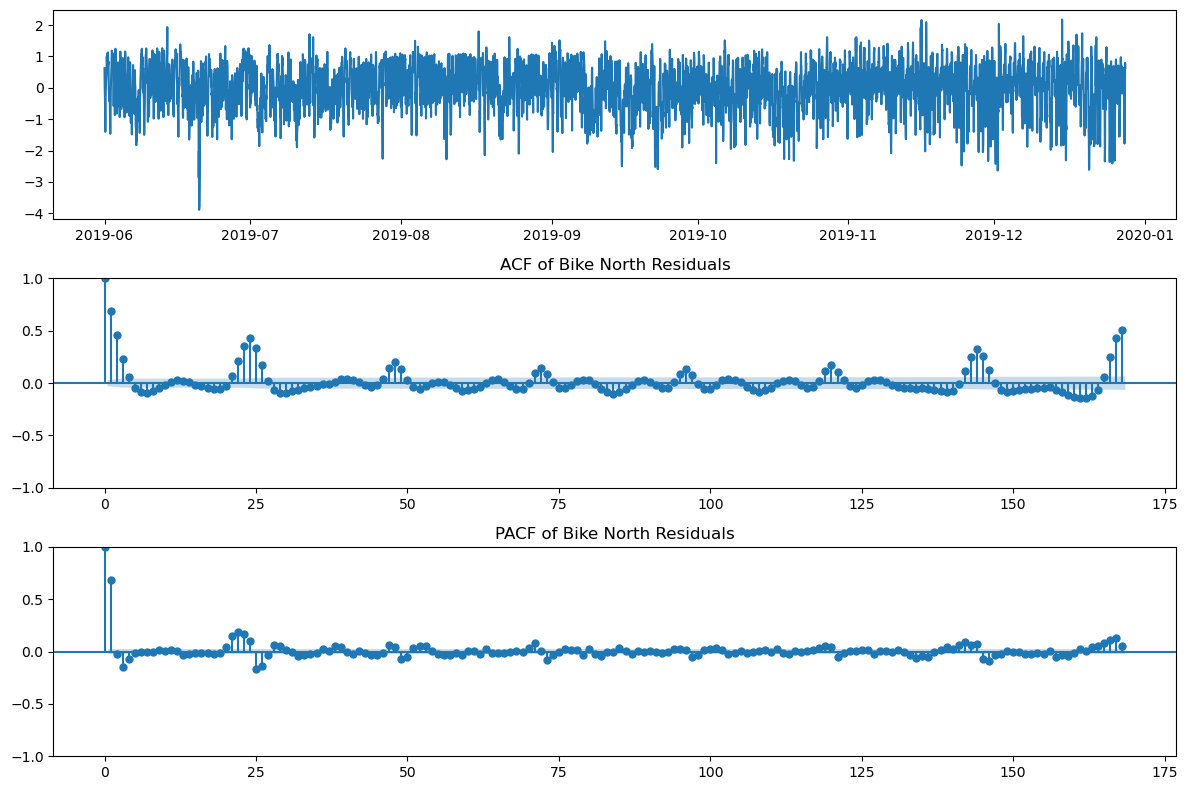

In [27]:
#Plot Residuals
fig, (ax1,ax2,ax3) = plt.subplots(3 , 1,  figsize=(12, 8))
ax1.plot(df_train['bike_north_harmonic_gam_resid'])
plot_acf(df_train['bike_north_harmonic_gam_resid'], lags = 24*7, ax = ax2, title = 'ACF of Bike North Residuals')
plot_pacf(df_train['bike_north_harmonic_gam_resid'], lags = 24*7, ax = ax3, title = 'PACF of Bike North Residuals')
plt.tight_layout()
plt.show()



The residuals resemble a white noise process much moreso than the original dataset. The ACF plot decays to zero, although there is still significant autocorrelation at about 24 hours at 168 hours. The PACF plot displays a similar story, however it communicates that much of the influence on the ACF plot is due to indirect relationships.

In [28]:
#Test for stationarity
boxTest = acorr_ljungbox(df_train['bike_north_harmonic_gam_resid'], lags=[168])
print(f"Ljung-Box: Test statistic = {boxTest.iloc[0]['lb_stat']:.4f}; p-value = {boxTest.iloc[0]['lb_pvalue']:.4f}")

adfTest = adfuller(df_train['bike_north_harmonic_gam_resid'], autolag='AIC')
print(f"ADF: Test statistic = {adfTest[0]:.4f}; p-value = {adfTest[1]:.4f}")

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    kpssTest = kpss(df_train['bike_north_harmonic_gam_resid'], regression='c', nlags='auto')
print(f"KPSS: Test statistic = {kpssTest[0]:.4f}; p-value = {kpssTest[1]:.4f}")


Ljung-Box: Test statistic = 13235.2285; p-value = 0.0000
ADF: Test statistic = -9.8013; p-value = 0.0000
KPSS: Test statistic = 0.1210; p-value = 0.1000


We reject the Ljung Box test, which tells us that there are still significant autocorrelations in the residuals.

We reject the ADF test, which tells us that the data displays evidence of stationarity

We fail to reject the KPSS test, which tells us that the data displays evidence of stationary around a deterministic trend.

In [30]:
#Identify the optimal SARIMA values without differencing. This process was iterative when creating this notebook.

# max_ar=list(range(0,4+1))
# max_ma=list(range(0,4+1))
# max_sar = list(range(0,1+1))
# max_sma = list(range(0,1+1))
# shape = (len(max_ar), len(max_ma), len(max_sar), len(max_sma))
#
# aic_matrix = np.full(shape, np.inf)
# aicc_matrix = np.full(shape, np.inf)
# bic_matrix = np.full(shape, np.inf)
#
# total = shape[0] * shape[1] * shape[2] * shape[3]
# progress = tqdm(total=total, desc="ARIMA Grid Search")
#
# for p in max_ar:
#     for q in max_ma:
#         for P in max_sar:
#             for Q in max_sma:
#                 try:
#                     with warnings.catch_warnings():
#                         warnings.simplefilter("ignore")
#                         fit_result = SARIMAX(
#                             df_train['bike_north_harmonic_gam_resid'],
#                             order=(p, 0, q),
#                             seasonal_order = (P,0,Q,24),
#                             enforce_stationarity = True,
#                             enforce_invertibility = True
#                         ).fit()
#
#                     k = len(fit_result.params)
#                     n = len(df_train['bike_north_harmonic_gam_resid'])
#                     aicc = fit_result.aic + (2 * k**2 + 2 * k) / (n - k - 1)
#
#                     aic_matrix[p, q, P, Q] = fit_result.aic
#                     aicc_matrix[p, q, P, Q] = aicc
#                     bic_matrix[p, q, P, Q] = fit_result.bic
#
#                 except Exception:
#
#                     pass
#
#                 progress.update(1)
#
# progress.close()
# min_idx = np.unravel_index(np.argmin(aicc_matrix), aicc_matrix.shape)
#
# p_best = min_idx[0]
# q_best = min_idx[1]
# P_best = min_idx[2]
# Q_best = min_idx[3]
# best_value = aicc_matrix[min_idx]
#
# print(p_best,
# q_best ,
# P_best,
# Q_best,
# best_value)

In [31]:
#Analyze the sorted plot of the aicc matrix

# plt.plot(aicc_matrix.flatten())

The purpose of plotting the sorted AICC matrix is to identify if the minimum present AICC values begin to display a plateau. If there is a significant negative slope at leading into the smallest values of the AICC matrix, then there is evidence that continued parameter searching would provide significantly better results.

In [32]:
#Fit the best performing SARIMAX model identified.
sarima_bike_north = SARIMAX(
                            df_train['bike_north_harmonic_gam_resid'],
                            order=(4, 0, 2),
                            seasonal_order = (1,0,1,24),
                            enforce_stationarity = True,
                            enforce_invertibility = True
                        ).fit()


df_train['bike_north_harmonic_gam_sarima_resid'] = sarima_bike_north.resid

C:\Users\conno\miniconda3\envs\isye6414\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
C:\Users\conno\miniconda3\envs\isye6414\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
C:\Users\conno\miniconda3\envs\isye6414\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


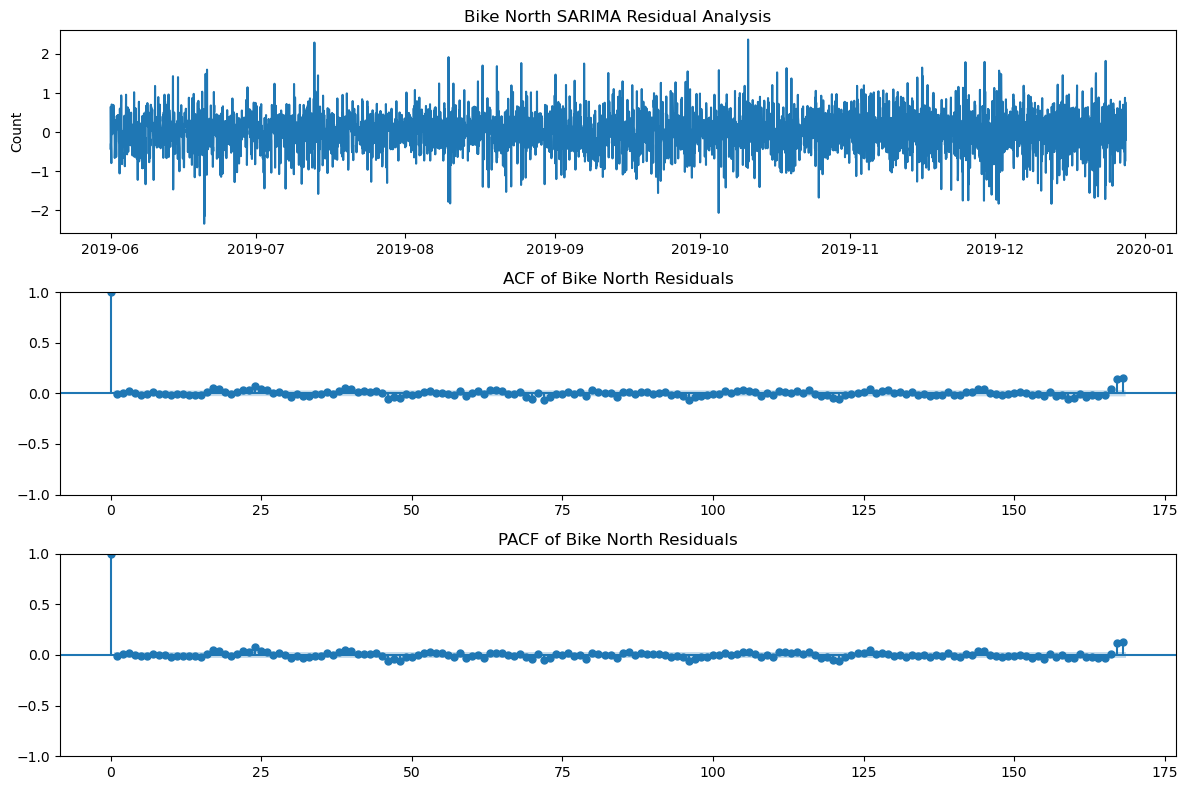

In [75]:
#Plot the ARIMA Residuals
fig, (ax1,ax2,ax3) = plt.subplots(3 , 1,  figsize=(12, 8))
ax1.plot(df_train['bike_north_harmonic_gam_sarima_resid'])
ax1.set_ylabel('Count')
ax1.set_title('Bike North SARIMA Residual Analysis')
plot_acf(df_train['bike_north_harmonic_gam_sarima_resid'], lags = 24*7, ax = ax2, title = 'ACF of Bike North Residuals')
plot_pacf(df_train['bike_north_harmonic_gam_sarima_resid'], lags = 24*7, ax = ax3, title = 'PACF of Bike North Residuals')
plt.tight_layout()
plt.show()

The plot of the residuals appear to be a white noise process. There is some minor clustering of variability that may be indicating the presence of conditional variance.

The ACF and PACF plots largely allude that the residuals exhibit weak stationarity.  There is some statistically significant, although very small, autocorrelation still remaining in the residuals.

In [34]:
#Check Ljung-Box Test
boxTest2 = acorr_ljungbox(df_train['bike_north_harmonic_gam_sarima_resid'], lags=[168], model_df = 7)
print(f"Ljung-Box: Test statistic = {boxTest2.iloc[0]['lb_stat']:.4f}; p-value = {boxTest2.iloc[0]['lb_pvalue']:.4f}")

Ljung-Box: Test statistic = 714.6584; p-value = 0.0000


The Ljung-Box test continues to display that there is significant correlation left in the model. This can be seen in the ACF plot as well, however the ACF values are small.

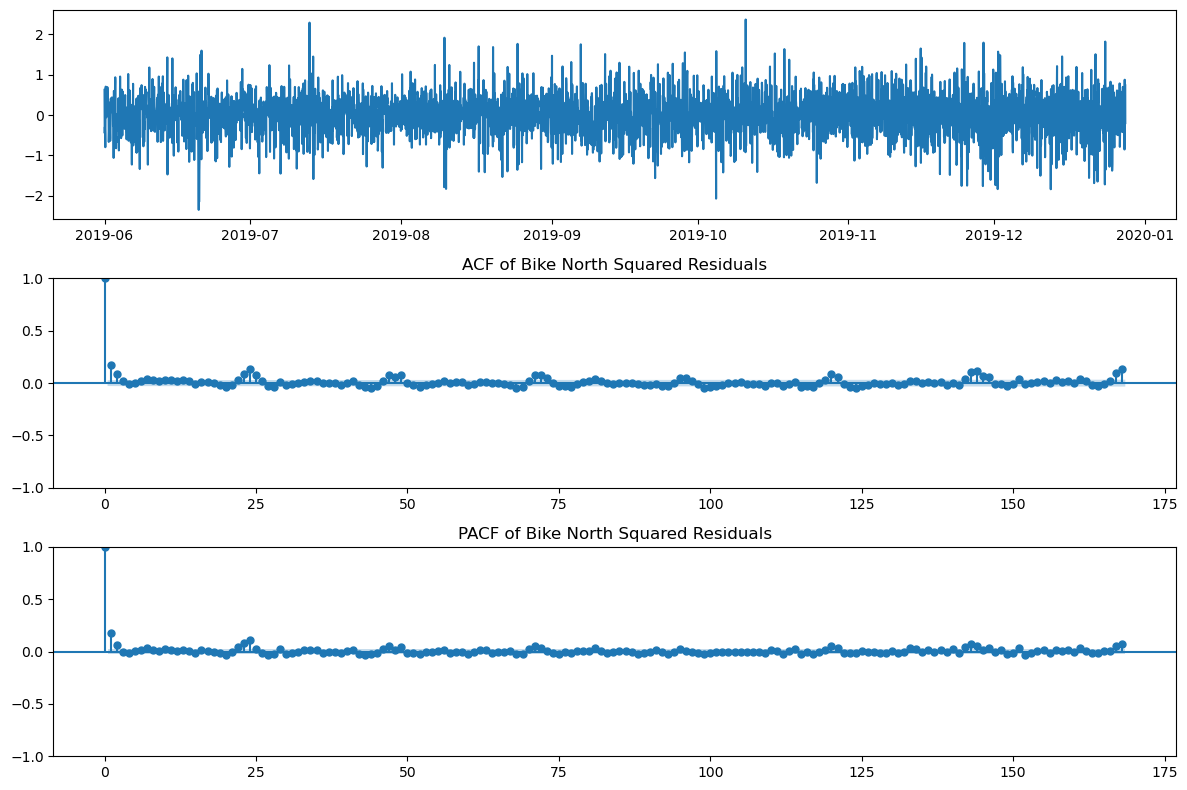

In [35]:
#Check the squared ACF and PACF to identify if there is significant conditional variance in the model.
fig, (ax1,ax2,ax3) = plt.subplots(3,1,figsize=(12, 8))
ax1.plot(df_train['bike_north_harmonic_gam_sarima_resid'])
plot_acf(df_train['bike_north_harmonic_gam_sarima_resid']**2, lags = 24*7, ax = ax2, title = 'ACF of Bike North Squared Residuals')
plot_pacf(df_train['bike_north_harmonic_gam_sarima_resid']**2, lags = 24*7, ax = ax3, title = 'PACF of Bike North Squared Residuals')
plt.tight_layout()
plt.show()

The plots of the squared residuals indicate that there is statistically significant conditional variance within the model, however it is not extreme. An ARCH or GARCH model would likely improve the confidence interval accuracy for the final predictions. This option was not pursued in this analysis.

In [36]:
#Get predictions from Spline Trend on Test Data
test_time_pts = np.arange(len(df_train['Bike North']), len(df_train['Bike North']) + len(df_test['Bike North']))

test_time_norm = (test_time_pts - time_pts.min()) / time_pts.max()

pred_spline_bike_north = spline_bike_north(test_time_norm)

In [37]:
#Get predictions from Harmonic Seasonality on Test Data
test_week_hour = (df_test['Bike North'].index.dayofweek * 24) + df_test['Bike North'].index.hour

df_test['cos1'] = np.cos(2 * np.pi * df_test['Bike North'].index.hour / 12)
df_test['sin1'] = np.sin(2 * np.pi * df_test['Bike North'].index.hour / 12)
df_test['cos2'] = np.cos(2 * np.pi * df_test['Bike North'].index.hour / 24)
df_test['sin2'] = np.sin(2 * np.pi * df_test['Bike North'].index.hour / 24)
df_test['cos3'] = np.cos(2 * np.pi * test_week_hour / 168)
df_test['sin3'] = np.sin(2 * np.pi * test_week_hour / 168)

pred_harmonic_gam_bike_north = harmonic_gam_bike_north.predict(df_test)

In [38]:
#Compute prediction that is translated back to the original dataset's values.
pred_sarima_bike_north = sarima_bike_north.forecast(steps=len(df_test['Bike North']))

final_trans_pred = pred_spline_bike_north + pred_harmonic_gam_bike_north.values + pred_sarima_bike_north.values

df_test['bike_north_final_pred'] = np.exp(final_trans_pred) - 1

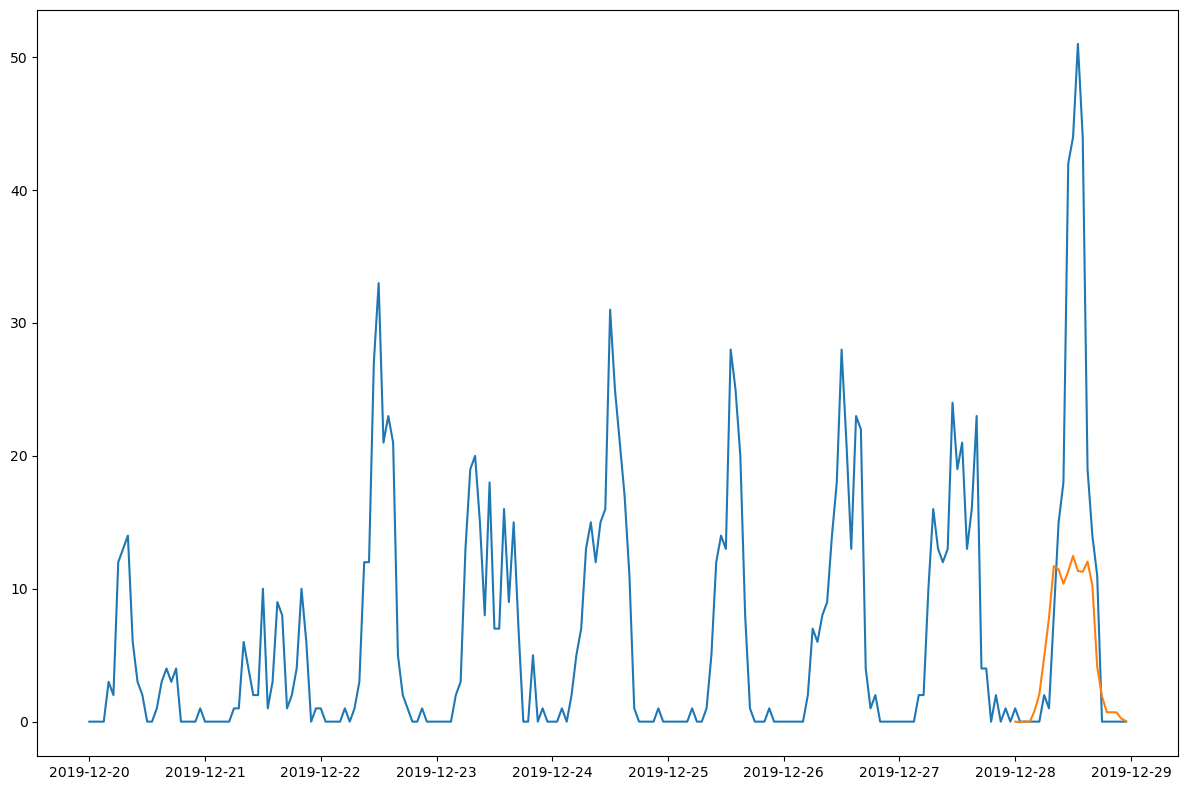

In [39]:
#Plot prediction
plt.figure(1,(12,8))
plt.plot(df['Bike North'].loc['2019-12-20':'2019-12-28'],label = 'Actual')
plt.plot(df_test['bike_north_final_pred'], label = 'SARIMA pred')
plt.tight_layout()
plt.show()

In [40]:
#Compute the Precision Measure for the prediction
df_test['bike_north_final_pred_resid'] = df_test['bike_north_final_pred'] - df_test['Bike North']

final_pred_pm = np.sum(df_test['bike_north_final_pred_resid']**2)/np.sum((df_test['Bike North']-np.mean(df_test['Bike North']))**2)
print(final_pred_pm)

0.7447021084014925


The PM value displays that the prediction error is less than the variability of the dataset. Since the PM is below 1, this is a good indicator that the model has useful predictive performance.

### VAR

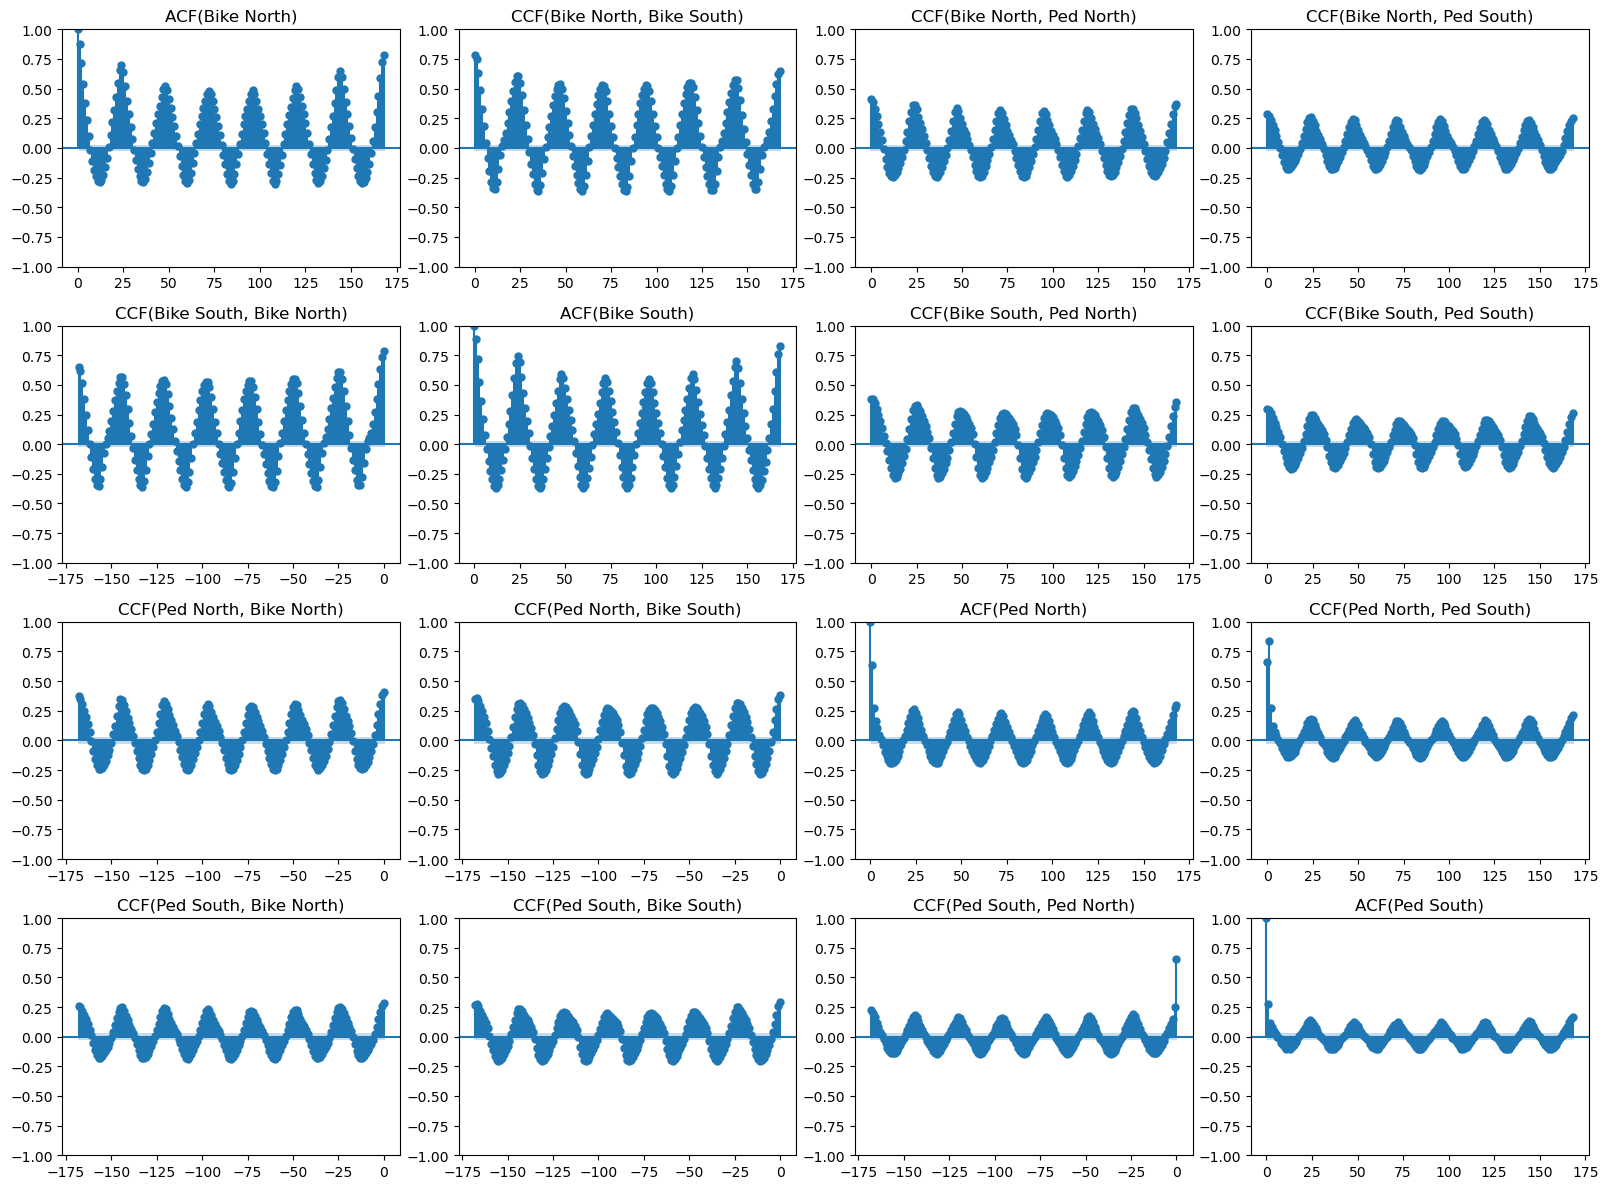

In [41]:
#Plot ACCF Grid of all individual variables
plot_accf_grid(df[['Bike North','Bike South','Ped North','Ped South']],lags=168, fig=plt.figure(figsize=(16, 12)))
plt.tight_layout()
plt.show()

Based on the ACCF Plots, Bike South looks to have the largest amount of cross correlation with Bike North

This next section largely repeats the decomposition that occurred on Bike North for Bike South

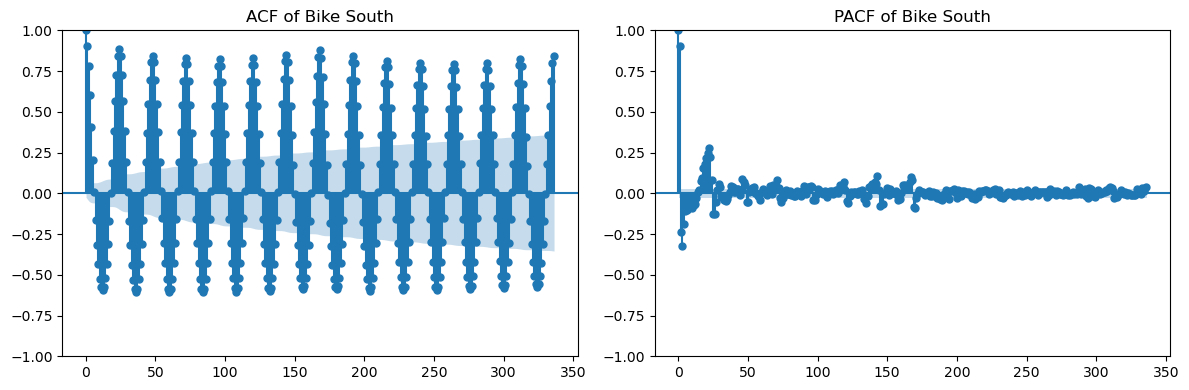

In [42]:

fig, (ax1,ax2) = plt.subplots(1 , 2, figsize=(12, 4))
plot_acf(df_train['Bike South'], lags = 24*14, ax = ax1, title = 'ACF of Bike South')
plot_pacf(df_train['Bike South'], lags = 24*14, ax = ax2, title = 'PACF of Bike South')
plt.tight_layout()
plt.show()

In [43]:
time_pts = np.arange(len(df_train['Bike South']))
time_norm = (time_pts - time_pts.min()) / time_pts.max()
spline_bike_south = UnivariateSpline(time_norm, df_train['Bike South'], s=len(df_train['Bike South'])*10)
spline_fit_bike_south = spline_bike_south(time_norm)
df_train['bike_south_fit_gam'] = spline_fit_bike_south
df_train['bike_south_gam_resid'] = df_train['Bike South'] - df_train['bike_south_fit_gam']

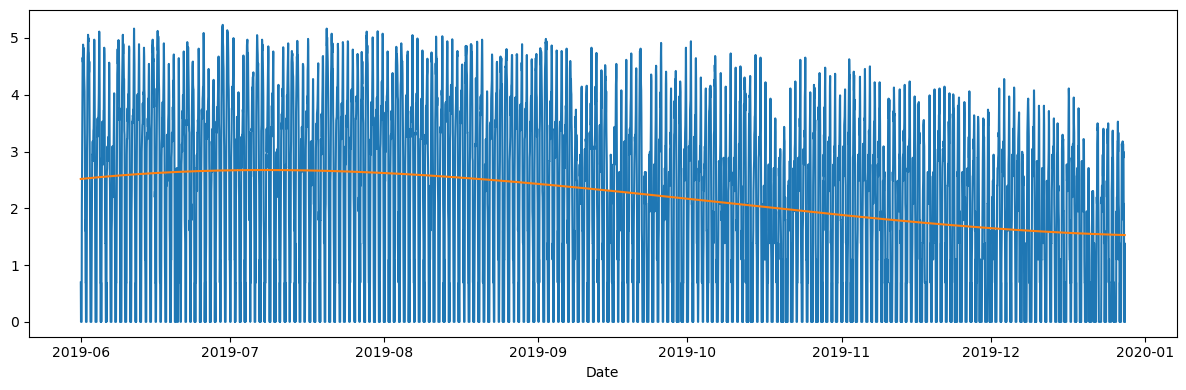

In [44]:
fig, ax = plt.subplots(figsize = (12,4))
plt.plot(df_train.index, df_train['Bike South'])
plt.plot(df_train.index, df_train['bike_south_fit_gam'])
plt.xlabel('Date')
plt.tight_layout()
plt.show()

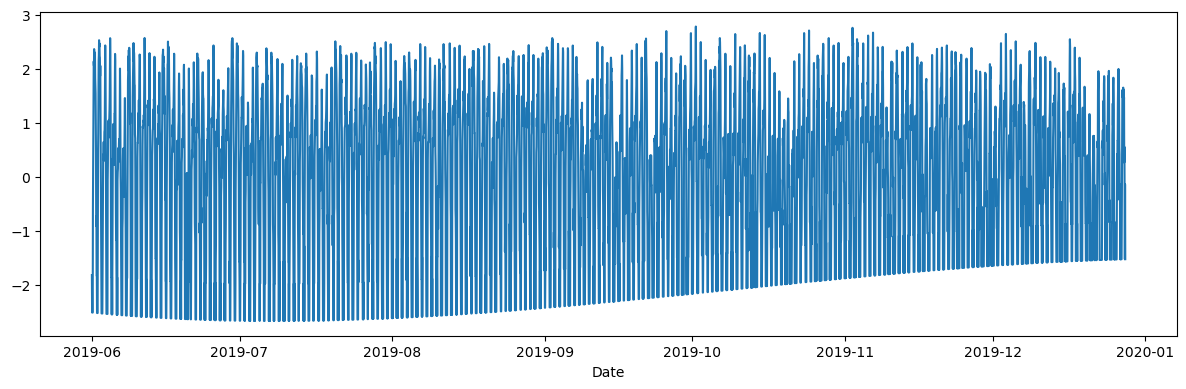

In [45]:
plt.figure(1,(12,4))
plt.plot(df_train.index, df_train['bike_south_gam_resid'])
plt.xlabel('Date')
plt.tight_layout()
plt.show()

In [46]:
week_hour = df_train.index.dayofweek*24 + df_train.index.hour

df_train['bike_south_cos1'] = np.cos(2 * np.pi * (df_train.index.hour) / 12)
df_train['bike_south_sin1'] = np.sin(2 * np.pi * (df_train.index.hour) / 12)
df_train['bike_south_cos2'] = np.cos(2 * np.pi * (df_train.index.hour) / 24)
df_train['bike_south_sin2'] = np.sin(2 * np.pi * (df_train.index.hour) / 24)
df_train['bike_south_cos3'] = np.cos(2 * np.pi * (week_hour) / 168)
df_train['bike_south_sin3'] = np.sin(2 * np.pi * (week_hour) / 168)

harmonic_gam_bike_south = smf.ols(formula='bike_south_gam_resid ~ bike_south_cos1 + bike_south_sin1 + bike_south_cos2 + bike_south_sin2 + bike_south_cos3 + bike_south_sin3', data=df_train).fit()
print(harmonic_gam_bike_south.summary())

df_train['bike_south_harmonic_gam_resid'] = harmonic_gam_bike_south.resid

                             OLS Regression Results                             
Dep. Variable:     bike_south_gam_resid   R-squared:                       0.814
Model:                              OLS   Adj. R-squared:                  0.814
Method:                   Least Squares   F-statistic:                     3677.
Date:                  Fri, 01 May 2026   Prob (F-statistic):               0.00
Time:                          20:47:45   Log-Likelihood:                -5072.0
No. Observations:                  5040   AIC:                         1.016e+04
Df Residuals:                      5033   BIC:                         1.020e+04
Df Model:                             6                                         
Covariance Type:              nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept       -7.372

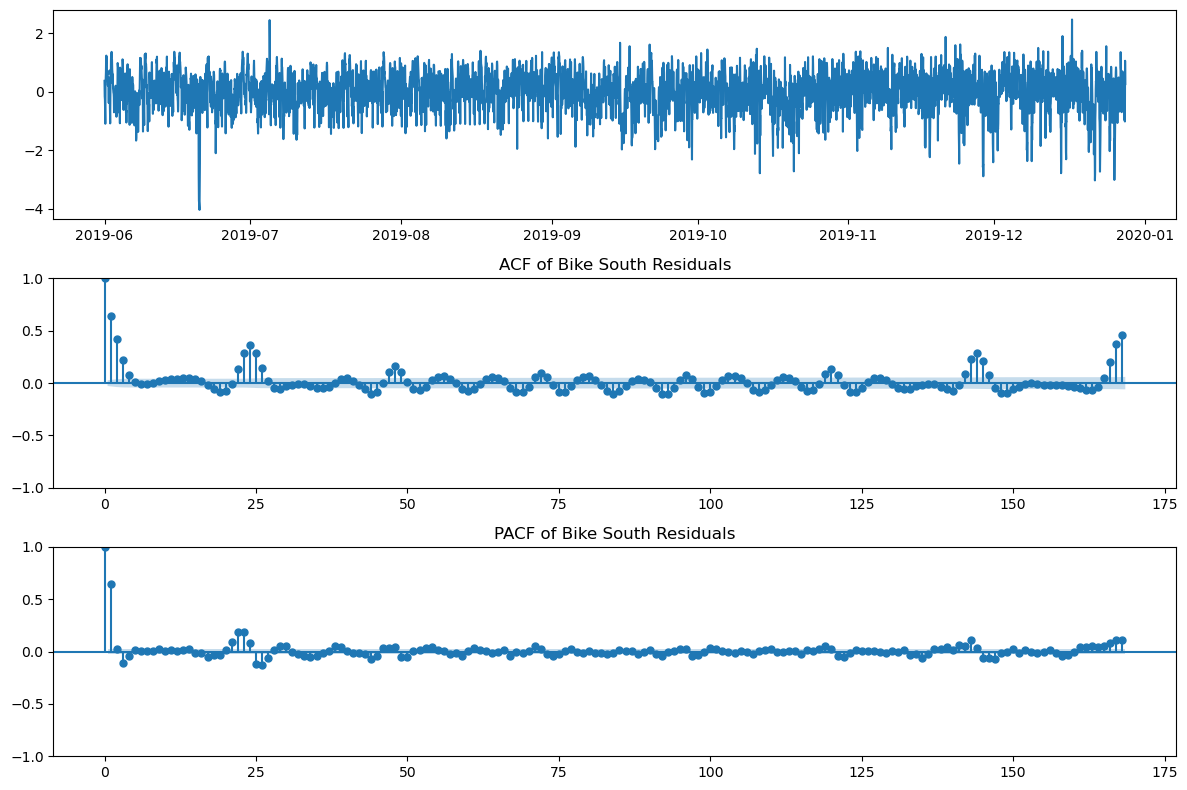

In [47]:
fig, (ax1,ax2,ax3) = plt.subplots(3 , 1,  figsize=(12, 8))
ax1.plot(df_train['bike_south_harmonic_gam_resid'])
plot_acf(df_train['bike_south_harmonic_gam_resid'], lags = 24*7, ax = ax2, title = 'ACF of Bike South Residuals')
plot_pacf(df_train['bike_south_harmonic_gam_resid'], lags = 24*7, ax = ax3, title = 'PACF of Bike South Residuals')
plt.tight_layout()
plt.show()

In [48]:
boxTest = acorr_ljungbox(df_train['bike_south_harmonic_gam_resid'], lags=[168])
print(f"Ljung-Box: Test statistic = {boxTest.iloc[0]['lb_stat']:.4f}; p-value = {boxTest.iloc[0]['lb_pvalue']:.4f}")

adfTest = adfuller(df_train['bike_south_harmonic_gam_resid'], autolag='AIC')
print(f"ADF: Test statistic = {adfTest[0]:.4f}; p-value = {adfTest[1]:.4f}")

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    kpssTest = kpss(df_train['bike_south_harmonic_gam_resid'], regression='c', nlags='auto')
print(f"KPSS: Test statistic = {kpssTest[0]:.4f}; p-value = {kpssTest[1]:.4f}")

Ljung-Box: Test statistic = 10371.9606; p-value = 0.0000
ADF: Test statistic = -9.9463; p-value = 0.0000
KPSS: Test statistic = 0.1018; p-value = 0.1000


Very similar test results to Bike North, which is not surprising given the very similar decomposition and underlying data

In [49]:
# max_ar=list(range(0,4+1))
# max_ma=list(range(0,4+1))
# max_sar = list(range(0,1+1))
# max_sma = list(range(0,1+1))
# shape = (len(max_ar), len(max_ma), len(max_sar), len(max_sma))
#
# aic_matrix = np.full(shape, np.inf)
# aicc_matrix = np.full(shape, np.inf)
# bic_matrix = np.full(shape, np.inf)
#
# total = shape[0] * shape[1] * shape[2] * shape[3]
# progress = tqdm(total=total, desc="ARIMA Grid Search")
#
# for p in max_ar:
#     for q in max_ma:
#         for P in max_sar:
#             for Q in max_sma:
#                 try:
#                     with warnings.catch_warnings():
#                         warnings.simplefilter("ignore")
#                         fit_result = SARIMAX(
#                             df_train['bike_south_harmonic_gam_resid'],
#                             order=(p, 0, q),
#                             seasonal_order = (P,0,Q,24),
#                             enforce_stationarity = True,
#                             enforce_invertibility = True
#                         ).fit()
#
#                     k = len(fit_result.params)
#                     n = len(df_train['bike_south_harmonic_gam_resid'])
#                     aicc = fit_result.aic + (2 * k**2 + 2 * k) / (n - k - 1)
#
#                     aic_matrix[p, q, P, Q] = fit_result.aic
#                     aicc_matrix[p, q, P, Q] = aicc
#                     bic_matrix[p, q, P, Q] = fit_result.bic
#
#                 except Exception:
#
#                     pass
#
#                 progress.update(1)
#
# progress.close()
# min_idx = np.unravel_index(np.argmin(aicc_matrix), aicc_matrix.shape)
#
# p_best = min_idx[0]
# q_best = min_idx[1]
# P_best = min_idx[2]
# Q_best = min_idx[3]
# best_value = aicc_matrix[min_idx]
#
# print(p_best,
# q_best ,
# P_best,
# Q_best,
# best_value)

In [50]:
# plt.plot(aicc_matrix.flatten())

In [51]:
sarima_bike_south = SARIMAX(
                            df_train['bike_south_harmonic_gam_resid'],
                            order=(4, 0, 2),
                            seasonal_order = (1,0,1,24),
                            enforce_stationarity = True,
                            enforce_invertibility = True
                        ).fit()

df_train['bike_south_harmonic_gam_sarima_resid'] = sarima_bike_south.resid

C:\Users\conno\miniconda3\envs\isye6414\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
C:\Users\conno\miniconda3\envs\isye6414\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
C:\Users\conno\miniconda3\envs\isye6414\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


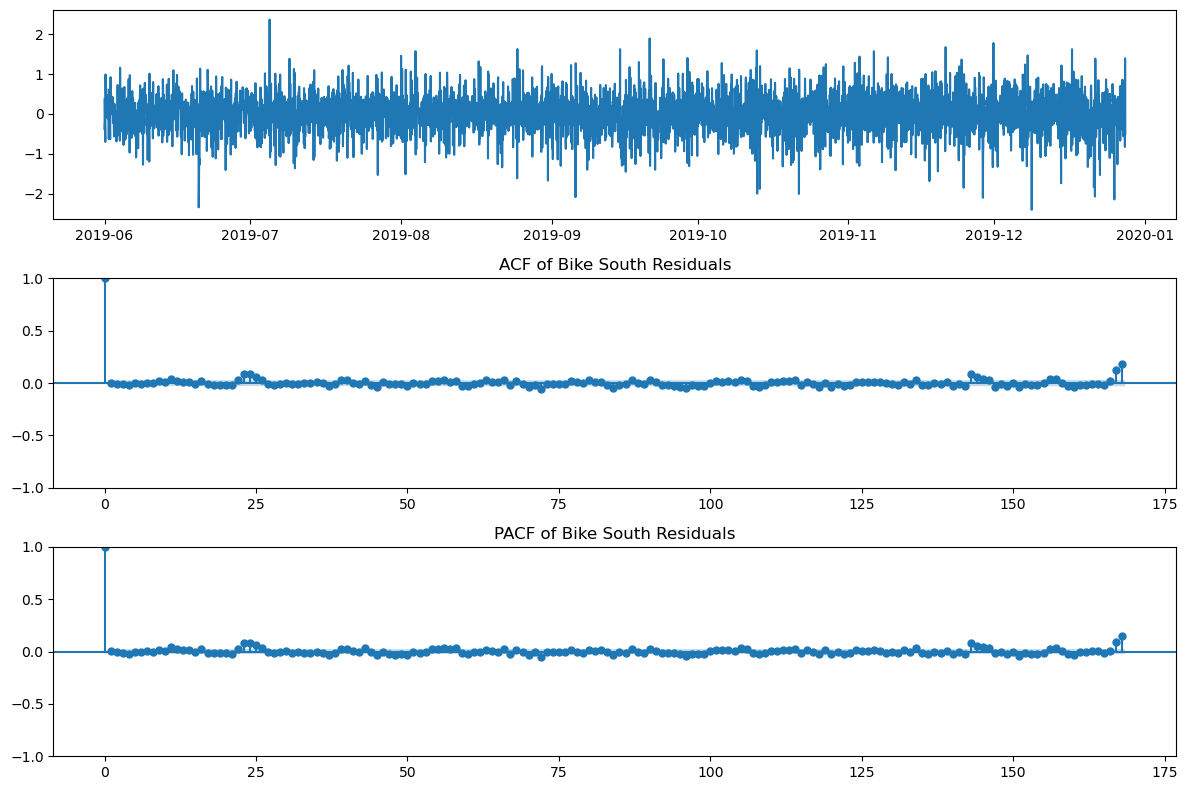

In [52]:
fig, (ax1,ax2,ax3) = plt.subplots(3 , 1,  figsize=(12, 8))
ax1.plot(df_train['bike_south_harmonic_gam_sarima_resid'])
plot_acf(df_train['bike_south_harmonic_gam_sarima_resid'], lags = 24*7, ax = ax2, title = 'ACF of Bike South Residuals')
plot_pacf(df_train['bike_south_harmonic_gam_sarima_resid'], lags = 24*7, ax = ax3, title = 'PACF of Bike South Residuals')
plt.tight_layout()
plt.show()

In [53]:
#Create VAR Model
var_data = pd.DataFrame({'Bike North': df_train['bike_north_harmonic_gam_sarima_resid'],'Bike South': df_train['bike_south_harmonic_gam_sarima_resid']})

var_model = VAR(var_data)
varSelect = var_model.select_order(maxlags=50, trend='c')

print(varSelect.summary())

var_model = VAR(var_data).fit(maxlags=15, trend='c')

C:\Users\conno\miniconda3\envs\isye6414\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -3.146      -3.143     0.04304      -3.145
1       -3.206      -3.199     0.04050      -3.204
2       -3.221      -3.208     0.03992      -3.216
3       -3.225      -3.207     0.03976      -3.219
4       -3.236      -3.213     0.03931      -3.228
5       -3.243      -3.214     0.03904      -3.233
6       -3.251      -3.218     0.03872      -3.240
7       -3.262      -3.223     0.03831      -3.248
8       -3.266      -3.221     0.03818      -3.250
9       -3.266      -3.216     0.03816      -3.249
10      -3.269      -3.214     0.03805      -3.250
11      -3.285      -3.225     0.03744      -3.264
12      -3.305      -3.239     0.03671      -3.282
13      -3.318      -3.248     0.03622      -3.293
14      -3.323      -3.247     0.03604      -3.296
15      -3.330     -3.249*     0.03579      -3.302
16      -3.332      -3.245     

C:\Users\conno\miniconda3\envs\isye6414\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


A Var_Model with 15 lags was selected due to the results of the BIC from varSelect

ARCH Test for Conditional Variance Assumption
(Lagrange Multiplier test p-values)
 Bike North: 5.583744936676546e-35, Bike South: 1.506057302948452e-39

Normality Test for Normality Assumption
normality (skew and kurtosis) test. H_0: data generated by normally-distributed process. Conclusion: reject H_0 at 5% significance level.
Test statistic Critical value p-value df
----------------------------------------
         1474.          9.488   0.000  4
----------------------------------------

Serial Correlation Test
Portmanteau-test for residual autocorrelation. H_0: residual autocorrelation up to lag 16 is zero. Conclusion: reject H_0 at 5% significance level.
Test statistic Critical value p-value df
----------------------------------------
         43.22          9.488   0.000  4
----------------------------------------

Unstable Root Count: 0


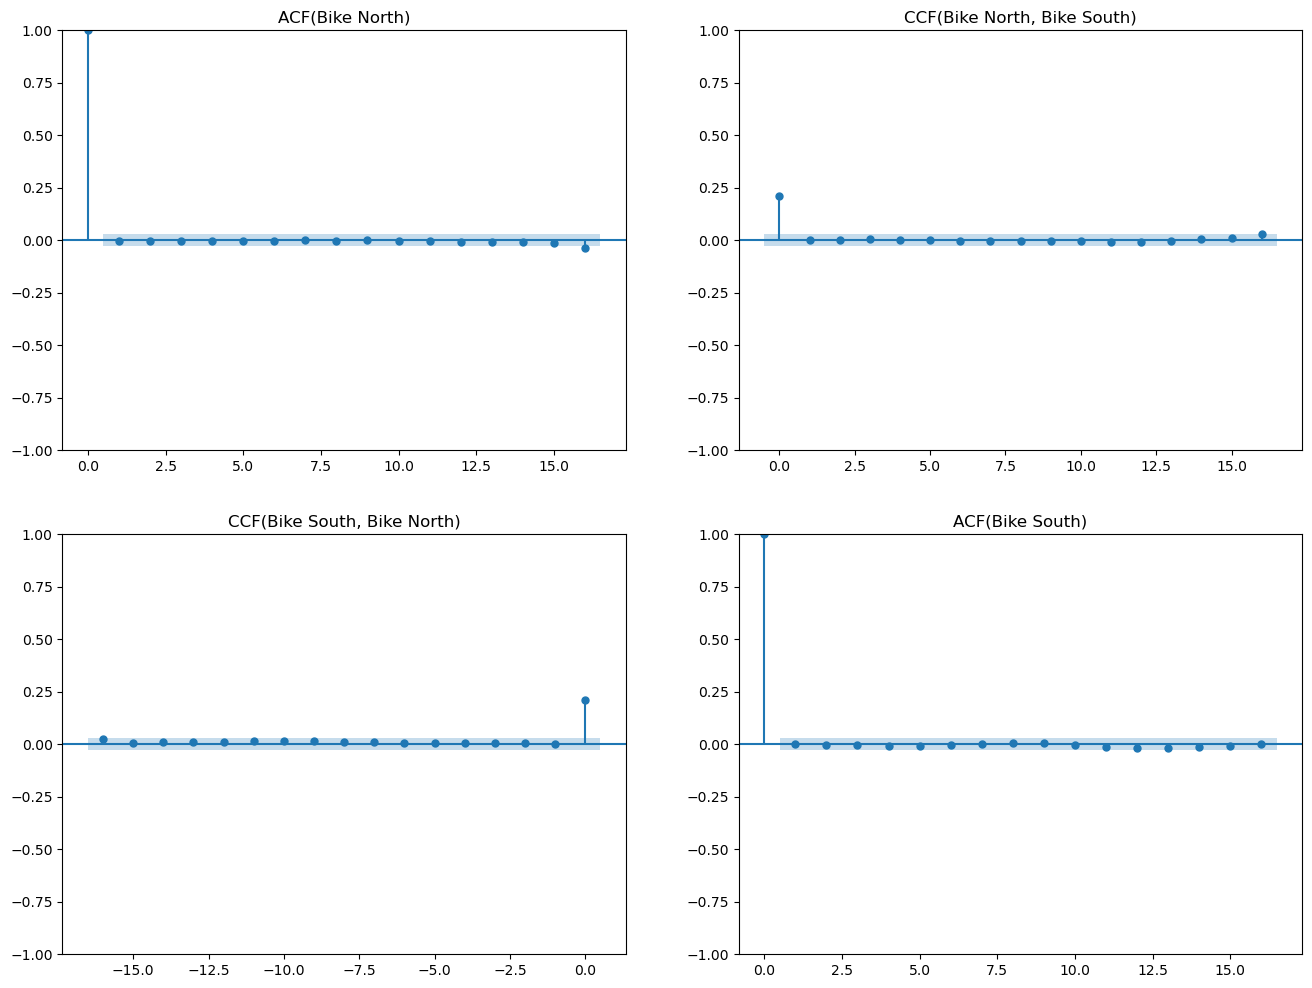

In [54]:
#Perform Goodness of Fit Tests
resid_var = var_model.resid

print("ARCH Test for Conditional Variance Assumption")
bike_north, bike_south = het_arch(resid_var['Bike North'])[1], het_arch(resid_var['Bike South'])[1]
print(f"(Lagrange Multiplier test p-values)\n Bike North: {bike_north}, Bike South: {bike_south}")

print("\nNormality Test for Normality Assumption")
print(var_model.test_normality().summary())

# Serial Correlation
print("\nSerial Correlation Test")
print(var_model.test_whiteness(nlags=16).summary())
acf = plot_accf_grid(resid_var, lags=16, fig=plt.figure(figsize=(16, 12)))

# Roots (NOTE: these are the inverse root)
print(f"\nUnstable Root Count: {np.sum(np.abs(var_model.roots) < 1)}")

All tests indicate goodness of fit issues with VAR. There is also some remaining contemporaneous correlation in the CCF plots, which VAR was not able to capture.

A major consequence of the lack of goodness of fit is that the confidence intervals that are generated from the VAR model are likely not going to be accurate.

In [55]:
#Identify last 15 rows in VAR train, since the VAR model will require this for prediction.
var_pred = var_model.forecast(
    y=df_train[['bike_north_harmonic_gam_sarima_resid','bike_south_harmonic_gam_sarima_resid']].iloc[-15:].values, steps=len(df_test['Bike South']))

In [56]:
#Predict Bike North with VAR Model included
final_trans_var_pred = pred_spline_bike_north + pred_harmonic_gam_bike_north.values + pred_sarima_bike_north.values + var_pred[:,0]

df_test['bike_north_final_var_pred'] = np.exp(final_trans_var_pred) - 1

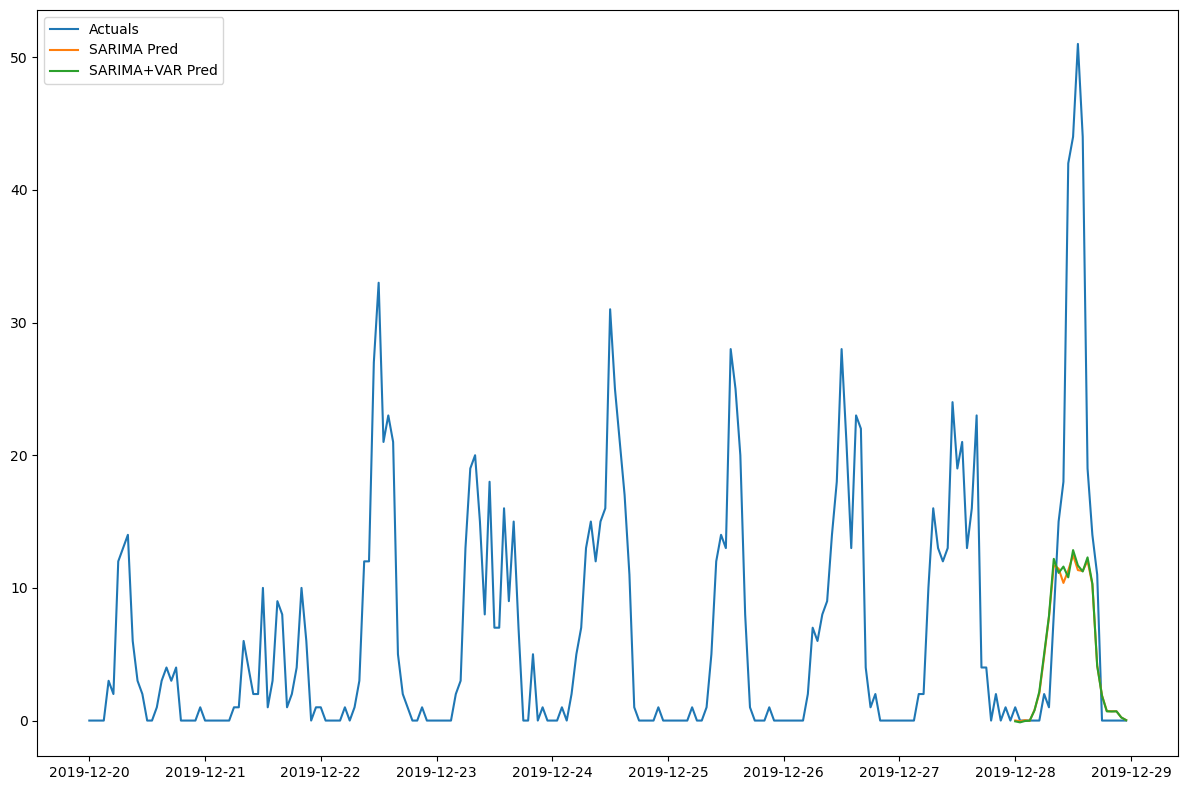

In [57]:
#Plot prediction overlayed on original plot
plt.figure(1,(12,8))
plt.plot(df['Bike North'].loc['2019-12-20':'2019-12-28'], label ='Actuals')
plt.plot(df_test['bike_north_final_pred'],label = 'SARIMA Pred')
plt.plot(df_test['bike_north_final_var_pred'],label = 'SARIMA+VAR Pred')
plt.legend()
plt.tight_layout()
plt.show()

In [58]:
#Calculate PM
df_test['bike_north_final_var_pred_resid'] = df_test['bike_north_final_var_pred'] - df_test['Bike North']

final_var_pred_pm = np.sum(df_test['bike_north_final_var_pred_resid']**2)/np.sum((df_test['Bike North']-np.mean(df_test['Bike North']))**2)
print(final_pred_pm)

0.7447021084014925


This prediction measure value is nearly identical to the SARIMA PM value. The plot displays why this is the case. Both models predicted nearly identically, with the VAR model slightly overpredicting the values in the SARIMA model.

### SARIMAX

In [72]:
# Identified coordinates for the Burke-Gilman Trail North of NE 70th Street.
latitude = 47.67
longitude = -122.26

# Source: https://open-meteo.com/en/docs
url = "https://archive-api.open-meteo.com/v1/archive"

params = {
    "latitude": latitude,
    "longitude": longitude,
    "start_date": "2019-06-01",
    "end_date": "2020-01-01",
    "hourly": "precipitation",
    "timezone_abbreviation": "ET"
}

request = requests.get(url, params=params)
weather_data = request.json()

rain_df = pd.DataFrame({"Date": pd.to_datetime(weather_data["hourly"]["time"]), "Precipitation": weather_data["hourly"]["precipitation"]})

rain_df.set_index("Date", inplace=True)


In [60]:
rain_df_train = rain_df.loc[:np.max(df_train.index)].copy()
rain_df_test = rain_df.loc[np.max(df_train.index)+pd.Timedelta(hours=1):np.max(df_train.index)+pd.Timedelta(hours=24)]

In [61]:
sarima_exog_bike_north = SARIMAX(
                            endog = df_train['bike_north_harmonic_gam_resid'],
                            exog = rain_df_train,
                            order=(4, 0, 2),
                            seasonal_order = (1,0,1,24),
                            enforce_stationarity = True,
                            enforce_invertibility = True
                        ).fit()


df_train['bike_north_harmonic_gam_sarima_exog_resid'] = sarima_exog_bike_north.resid

C:\Users\conno\miniconda3\envs\isye6414\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
C:\Users\conno\miniconda3\envs\isye6414\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
C:\Users\conno\miniconda3\envs\isye6414\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [62]:
sarima_exog_bike_north.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                       
============================================================================================
Dep. Variable:        bike_north_harmonic_gam_resid   No. Observations:                 5040
Model:             SARIMAX(4, 0, 2)x(1, 0, [1], 24)   Log Likelihood               -3256.745
Date:                              Fri, 01 May 2026   AIC                           6533.491
Time:                                      20:49:09   BIC                           6598.742
Sample:                                  06-01-2019   HQIC                          6556.351
                                       - 12-27-2019                                         
Covariance Type:                                opg                                         
=================================================================================
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Precipitation    -0.0819      0.020     -4.177      0.000      -0.120      -0.043
ar.L1             1.8089      0.060     30.153      0.000       1.691       1.926
ar.L2            -1.1193      0.076    -14.814      0.000      -1.267      -0.971
ar.L3             0.0828      0.033      2.537      0.011       0.019       0.147
ar.L4             0.0857      0.023      3.718      0.000       0.041       0.131
ma.L1            -1.2702      0.060    -21.344      0.000      -1.387      -1.154
ma.L2             0.6613      0.043     15.224      0.000       0.576       0.746
ar.S.L24          0.9956      0.001    719.758      0.000       0.993       0.998
ma.S.L24         -0.9293      0.005   -182.924      0.000      -0.939      -0.919
sigma2            0.2093      0.003     67.859      0.000       0.203       0.215
===================================================================================
Ljung-Box (L1) (Q):                   1.40   Jarque-Bera (JB):               725.02
Prob(Q):                              0.24   Prob(JB):                         0.00
Heteroskedasticity (H):               1.44   Skew:                            -0.12
Prob(H) (two-sided):                  0.00   Kurtosis:                         4.84
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

All coefficients within the VAR model are statistically significant.

In [63]:
#Compute prediction that is translated back to the original dataset's values.
pred_sarima_exog_bike_north = sarima_exog_bike_north.forecast(steps=len(df_test['Bike North']),exog = rain_df_test)

In [64]:
#Predict Bike North with VAR Model included
final_trans_sarima_exog_pred = pred_spline_bike_north + pred_harmonic_gam_bike_north.values + pred_sarima_exog_bike_north.values

df_test['bike_north_final_sarima_exog_pred'] = np.exp(final_trans_sarima_exog_pred) - 1

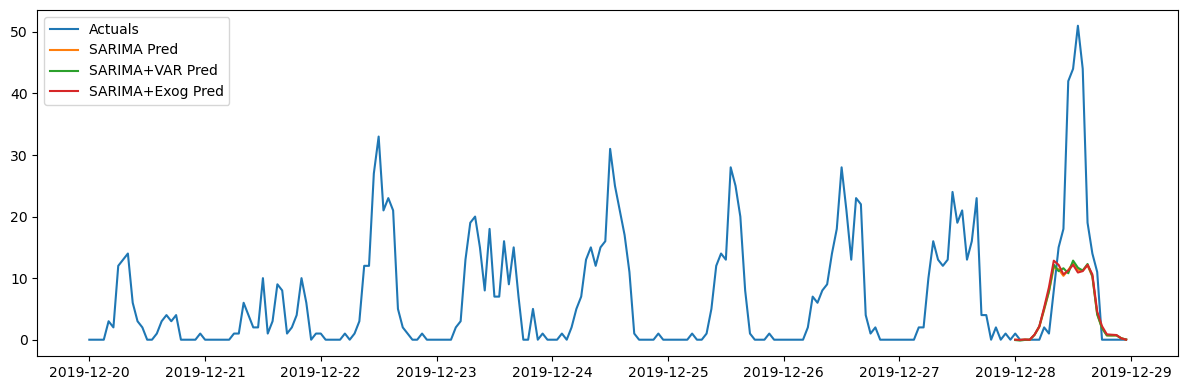

In [65]:
#Plot prediction overlayed on original plot
plt.figure(1,(12,4))
plt.plot(df['Bike North'].loc['2019-12-20':'2019-12-28'], label ='Actuals')
plt.plot(df_test['bike_north_final_pred'],label = 'SARIMA Pred')
plt.plot(df_test['bike_north_final_var_pred'],label = 'SARIMA+VAR Pred')
plt.plot(df_test['bike_north_final_sarima_exog_pred'],label = 'SARIMA+Exog Pred')
plt.legend()
plt.tight_layout()
plt.show()

The addition of the exogenous precipitation variable did not impact the prediction on December 28th. This is because December 28th, 2019 contained no precipitation.

Next, I will analyze the performance of all 3 models over the course of 10 days in December.

### Prediction Performance (2019-12-20 - 2019-12-31)

In [66]:
def SARIMA_Model(df_train, df_test):
    # Fit Spline Regression to extract macro trend
    time_pts = np.arange(len(df_train['Bike North']))
    time_norm = (time_pts - time_pts.min()) / time_pts.max()
    spline_bike_north = UnivariateSpline(time_norm, df_train['Bike North'], s=len(df_train['Bike North'])*10)
    spline_fit_bike_north = spline_bike_north(time_norm)
    df_train['bike_north_fit_gam'] = spline_fit_bike_north
    df_train['bike_north_gam_resid'] = df_train['Bike North'] - df_train['bike_north_fit_gam']

    #Seasonality Modeling
    week_hour = df_train.index.dayofweek*24 + df_train.index.hour
    df_train['cos1'] = np.cos(2 * np.pi * (df_train.index.hour) / 12)
    df_train['sin1'] = np.sin(2 * np.pi * (df_train.index.hour) / 12)
    df_train['cos2'] = np.cos(2 * np.pi * (df_train.index.hour) / 24)
    df_train['sin2'] = np.sin(2 * np.pi * (df_train.index.hour) / 24)
    df_train['cos3'] = np.cos(2 * np.pi * (week_hour) / 168)
    df_train['sin3'] = np.sin(2 * np.pi * (week_hour) / 168)

    harmonic_gam_bike_north = smf.ols(formula='bike_north_gam_resid ~ cos1 + sin1 + cos2 + sin2 + cos3 + sin3', data=df_train).fit()

    df_train['bike_north_harmonic_gam_resid'] = harmonic_gam_bike_north.resid

    #Fit the best performing SARIMAX model identified.
    sarima_bike_north = SARIMAX(
                            df_train['bike_north_harmonic_gam_resid'],
                            order=(4, 0, 2),
                            seasonal_order = (1,0,1,24),
                            enforce_stationarity = True,
                            enforce_invertibility = True
                        ).fit()

    df_train['bike_north_harmonic_gam_sarima_resid'] = sarima_bike_north.resid

    #Get predictions from Spline Trend on Test Data
    test_time_pts = np.arange(len(df_train['Bike North']), len(df_train['Bike North']) + len(df_test['Bike North']))

    test_time_norm = (test_time_pts - time_pts.min()) / time_pts.max()

    pred_spline_bike_north = spline_bike_north(test_time_norm)

    #Get predictions from Harmonic Seasonality on Test Data
    test_week_hour = (df_test['Bike North'].index.dayofweek * 24) + df_test['Bike North'].index.hour

    df_test['cos1'] = np.cos(2 * np.pi * df_test['Bike North'].index.hour / 12)
    df_test['sin1'] = np.sin(2 * np.pi * df_test['Bike North'].index.hour / 12)
    df_test['cos2'] = np.cos(2 * np.pi * df_test['Bike North'].index.hour / 24)
    df_test['sin2'] = np.sin(2 * np.pi * df_test['Bike North'].index.hour / 24)
    df_test['cos3'] = np.cos(2 * np.pi * test_week_hour / 168)
    df_test['sin3'] = np.sin(2 * np.pi * test_week_hour / 168)

    pred_harmonic_gam_bike_north = harmonic_gam_bike_north.predict(df_test)

    # Compute prediction that is translated back to the original dataset's values.
    pred_sarima_bike_north = sarima_bike_north.forecast(steps=len(df_test['Bike North']))

    final_trans_pred = pred_spline_bike_north + pred_harmonic_gam_bike_north.values + pred_sarima_bike_north.values

    df_test['bike_north_final_pred'] = np.exp(final_trans_pred) - 1

    return df_test['bike_north_final_pred']

In [67]:
def SARIMA_VAR_Model(df_train, df_test):
    #Bike North
    # Fit Spline Regression to extract macro trend
    time_pts = np.arange(len(df_train['Bike North']))
    time_norm = (time_pts - time_pts.min()) / time_pts.max()
    spline_bike_north = UnivariateSpline(time_norm, df_train['Bike North'], s=len(df_train['Bike North'])*10)
    spline_fit_bike_north = spline_bike_north(time_norm)
    df_train['bike_north_fit_gam'] = spline_fit_bike_north
    df_train['bike_north_gam_resid'] = df_train['Bike North'] - df_train['bike_north_fit_gam']

    #Seasonality Modeling
    week_hour = df_train.index.dayofweek*24 + df_train.index.hour
    df_train['cos1'] = np.cos(2 * np.pi * (df_train.index.hour) / 12)
    df_train['sin1'] = np.sin(2 * np.pi * (df_train.index.hour) / 12)
    df_train['cos2'] = np.cos(2 * np.pi * (df_train.index.hour) / 24)
    df_train['sin2'] = np.sin(2 * np.pi * (df_train.index.hour) / 24)
    df_train['cos3'] = np.cos(2 * np.pi * (week_hour) / 168)
    df_train['sin3'] = np.sin(2 * np.pi * (week_hour) / 168)

    harmonic_gam_bike_north = smf.ols(formula='bike_north_gam_resid ~ cos1 + sin1 + cos2 + sin2 + cos3 + sin3', data=df_train).fit()

    df_train['bike_north_harmonic_gam_resid'] = harmonic_gam_bike_north.resid

    #Fit the best performing SARIMAX model identified.
    sarima_bike_north = SARIMAX(
                            df_train['bike_north_harmonic_gam_resid'],
                            order=(4, 0, 2),
                            seasonal_order = (1,0,1,24),
                            enforce_stationarity = True,
                            enforce_invertibility = True
                        ).fit()

    df_train['bike_north_harmonic_gam_sarima_resid'] = sarima_bike_north.resid

    #Bike South
    # Fit Spline Regression to extract macro trend
    time_pts = np.arange(len(df_train['Bike South']))
    time_norm = (time_pts - time_pts.min()) / time_pts.max()
    spline_bike_south = UnivariateSpline(time_norm, df_train['Bike South'], s=len(df_train['Bike South'])*10)
    spline_fit_bike_south = spline_bike_south(time_norm)
    df_train['bike_south_fit_gam'] = spline_fit_bike_south
    df_train['bike_south_gam_resid'] = df_train['Bike South'] - df_train['bike_south_fit_gam']

    #Seasonality Modeling
    week_hour = df_train.index.dayofweek*24 + df_train.index.hour
    df_train['cos1'] = np.cos(2 * np.pi * (df_train.index.hour) / 12)
    df_train['sin1'] = np.sin(2 * np.pi * (df_train.index.hour) / 12)
    df_train['cos2'] = np.cos(2 * np.pi * (df_train.index.hour) / 24)
    df_train['sin2'] = np.sin(2 * np.pi * (df_train.index.hour) / 24)
    df_train['cos3'] = np.cos(2 * np.pi * (week_hour) / 168)
    df_train['sin3'] = np.sin(2 * np.pi * (week_hour) / 168)

    harmonic_gam_bike_south = smf.ols(formula='bike_south_gam_resid ~ cos1 + sin1 + cos2 + sin2 + cos3 + sin3', data=df_train).fit()

    df_train['bike_south_harmonic_gam_resid'] = harmonic_gam_bike_south.resid

    #Fit the best performing SARIMAX model identified.
    sarima_bike_south = SARIMAX(
                            df_train['bike_south_harmonic_gam_resid'],
                            order=(4, 0, 2),
                            seasonal_order = (1,0,1,24),
                            enforce_stationarity = True,
                            enforce_invertibility = True
                        ).fit()

    df_train['bike_south_harmonic_gam_sarima_resid'] = sarima_bike_south.resid

    #Create VAR Model
    var_data = pd.DataFrame({'Bike North': df_train['bike_north_harmonic_gam_sarima_resid'],'Bike South': df_train['bike_south_harmonic_gam_sarima_resid']})

    var_model = VAR(var_data).fit(maxlags=15, trend='c')

    #Identify last 15 rows in VAR train, since the VAR model will require this for prediction.
    var_pred = var_model.forecast(
    y=df_train[['bike_north_harmonic_gam_sarima_resid','bike_south_harmonic_gam_sarima_resid']].iloc[-15:].values, steps=len(df_test['Bike South']))

    #Get predictions from Spline Trend on Test Data
    test_time_pts = np.arange(len(df_train['Bike North']), len(df_train['Bike North']) + len(df_test['Bike North']))

    test_time_norm = (test_time_pts - time_pts.min()) / time_pts.max()

    pred_spline_bike_north = spline_bike_north(test_time_norm)

    #Get predictions from Harmonic Seasonality on Test Data
    test_week_hour = (df_test['Bike North'].index.dayofweek * 24) + df_test['Bike North'].index.hour

    df_test['cos1'] = np.cos(2 * np.pi * df_test['Bike North'].index.hour / 12)
    df_test['sin1'] = np.sin(2 * np.pi * df_test['Bike North'].index.hour / 12)
    df_test['cos2'] = np.cos(2 * np.pi * df_test['Bike North'].index.hour / 24)
    df_test['sin2'] = np.sin(2 * np.pi * df_test['Bike North'].index.hour / 24)
    df_test['cos3'] = np.cos(2 * np.pi * test_week_hour / 168)
    df_test['sin3'] = np.sin(2 * np.pi * test_week_hour / 168)

    pred_harmonic_gam_bike_north = harmonic_gam_bike_north.predict(df_test)

    # Compute prediction that is translated back to the original dataset's values.
    pred_sarima_bike_north = sarima_bike_north.forecast(steps=len(df_test['Bike North']))

    final_trans_var_pred = pred_spline_bike_north + pred_harmonic_gam_bike_north.values + pred_sarima_bike_north.values + var_pred[:,0]

    df_test['bike_north_final_var_pred'] = np.exp(final_trans_var_pred) - 1

    return df_test['bike_north_final_var_pred']

In [68]:
def SARIMAX_Model(df_train, df_test):
    # Fit Spline Regression to extract macro trend
    time_pts = np.arange(len(df_train['Bike North']))
    time_norm = (time_pts - time_pts.min()) / time_pts.max()
    spline_bike_north = UnivariateSpline(time_norm, df_train['Bike North'], s=len(df_train['Bike North'])*10)
    spline_fit_bike_north = spline_bike_north(time_norm)
    df_train['bike_north_fit_gam'] = spline_fit_bike_north
    df_train['bike_north_gam_resid'] = df_train['Bike North'] - df_train['bike_north_fit_gam']

    #Seasonality Modeling
    week_hour = df_train.index.dayofweek*24 + df_train.index.hour
    df_train['cos1'] = np.cos(2 * np.pi * (df_train.index.hour) / 12)
    df_train['sin1'] = np.sin(2 * np.pi * (df_train.index.hour) / 12)
    df_train['cos2'] = np.cos(2 * np.pi * (df_train.index.hour) / 24)
    df_train['sin2'] = np.sin(2 * np.pi * (df_train.index.hour) / 24)
    df_train['cos3'] = np.cos(2 * np.pi * (week_hour) / 168)
    df_train['sin3'] = np.sin(2 * np.pi * (week_hour) / 168)

    harmonic_gam_bike_north = smf.ols(formula='bike_north_gam_resid ~ cos1 + sin1 + cos2 + sin2 + cos3 + sin3', data=df_train).fit()

    df_train['bike_north_harmonic_gam_resid'] = harmonic_gam_bike_north.resid

    #Fit the best performing SARIMAX model identified.
    sarima_exog_bike_north = SARIMAX(
                            endog = df_train['bike_north_harmonic_gam_resid'],
                            exog = rain_df_train,
                            order=(4, 0, 2),
                            seasonal_order = (1,0,1,24),
                            enforce_stationarity = True,
                            enforce_invertibility = True
                        ).fit()


    df_train['bike_north_harmonic_gam_sarima_exog_resid'] = sarima_exog_bike_north.resid

    #Get predictions from Spline Trend on Test Data
    test_time_pts = np.arange(len(df_train['Bike North']), len(df_train['Bike North']) + len(df_test['Bike North']))

    test_time_norm = (test_time_pts - time_pts.min()) / time_pts.max()

    pred_spline_bike_north = spline_bike_north(test_time_norm)

    #Get predictions from Harmonic Seasonality on Test Data
    test_week_hour = (df_test['Bike North'].index.dayofweek * 24) + df_test['Bike North'].index.hour

    df_test['cos1'] = np.cos(2 * np.pi * df_test['Bike North'].index.hour / 12)
    df_test['sin1'] = np.sin(2 * np.pi * df_test['Bike North'].index.hour / 12)
    df_test['cos2'] = np.cos(2 * np.pi * df_test['Bike North'].index.hour / 24)
    df_test['sin2'] = np.sin(2 * np.pi * df_test['Bike North'].index.hour / 24)
    df_test['cos3'] = np.cos(2 * np.pi * test_week_hour / 168)
    df_test['sin3'] = np.sin(2 * np.pi * test_week_hour / 168)

    pred_harmonic_gam_bike_north = harmonic_gam_bike_north.predict(df_test)

    #Compute prediction that is translated back to the original dataset's values.
    pred_sarima_exog_bike_north = sarima_exog_bike_north.forecast(steps=len(df_test['Bike North']),exog = rain_df_test)

    #Predict Bike North with VAR Model included
    final_trans_sarima_exog_pred = pred_spline_bike_north + pred_harmonic_gam_bike_north.values + pred_sarima_exog_bike_north.values

    df_test['bike_north_final_sarima_exog_pred'] = np.exp(final_trans_sarima_exog_pred) - 1

    return df_test['bike_north_final_sarima_exog_pred']

In [69]:
dates = ['2019-12-20', '2019-12-21', '2019-12-22', '2019-12-23', '2019-12-24', '2019-12-25', '2019-12-26', '2019-12-27', '2019-12-28', '2019-12-29', '2019-12-30', '2019-12-31']

result_SARIMA = pd.Series()
result_VAR = pd.Series()
result_SARIMAX =pd.Series()
for i in range(len(dates)):
    df_train = np.log(df_train_orig + 1).copy()
    df_train = df_train[:pd.to_datetime(dates[i]) - pd.Timedelta(hours=1)]
    df_test = df.loc[dates[i]].copy()
    rain_df_train = rain_df.loc[:np.max(df_train.index)].copy()
    rain_df_test = rain_df.loc[np.max(df_train.index)+pd.Timedelta(hours=1):np.max(df_train.index)+pd.Timedelta(hours=24)]

    result_SARIMA = pd.concat([result_SARIMA,SARIMA_Model(df_train, df_test)])
    result_VAR = pd.concat([result_VAR,SARIMA_VAR_Model(df_train, df_test)])
    result_SARIMAX = pd.concat([result_SARIMAX,SARIMAX_Model(df_train, df_test)])

C:\Users\conno\miniconda3\envs\isye6414\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
C:\Users\conno\miniconda3\envs\isye6414\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
C:\Users\conno\miniconda3\envs\isye6414\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\conno\miniconda3\envs\isye6414\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
C:\Users\conno\miniconda3\envs\isye6414\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: Val

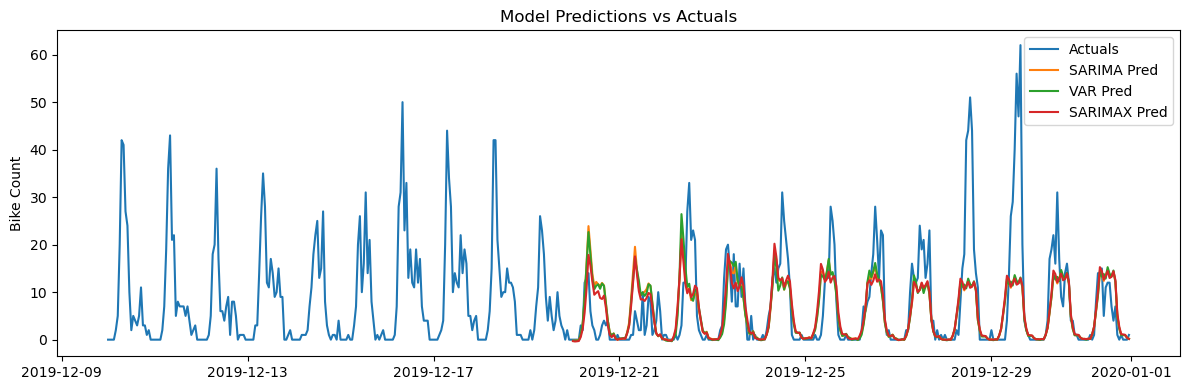

In [76]:
#Plot prediction overlayed on original plot
plt.figure(1,(12,4))
plt.plot(df['Bike North'].loc['2019-12-10':'2019-12-31'], label ='Actuals')
plt.plot(result_SARIMA,label = 'SARIMA Pred')
plt.plot(result_VAR,label = 'VAR Pred')
plt.plot(result_SARIMAX,label = 'SARIMAX Pred')
plt.title('Model Predictions vs Actuals')
plt.ylabel('Bike Count')
plt.legend()
plt.tight_layout()
plt.show()

From external research, there was a very significant downpour on 2019-12-20 and 2019-12-21. The SARIMAX model performs nearly identically to the other models in days without precipitation, and displays a noticeable decrease in prediction in days with precipitation.

All 3 models appear to represent the mean of the daylight period well, but they struggle to capture the variance within this period. This may be due to the log transform that was utilized for the df_train dataset. The log transform is still worthwhile as it greatly reduced the heteroskedasticity in the original dataset, however the transform decreased the signals of the variability of the original dataset to the models that were trained downstream likely causing them to not accurately account for the impact of the variability on the non-transformed dataset.

In [71]:
performance_measurements = pd.merge(df['Bike North'],result_SARIMA.rename('SARIMA Pred'), left_index = True, right_index = True)
performance_measurements['VAR Pred'] = result_VAR
performance_measurements['SARIMAX PRED'] = result_SARIMAX
performance_measurements['SARIMA Pred Resid'] = result_SARIMA - performance_measurements['Bike North']
performance_measurements['VAR Pred Resid'] = result_VAR - performance_measurements['Bike North']
performance_measurements['SARIMAX Pred Resid'] = result_SARIMAX - performance_measurements['Bike North']


PM_SARIMA = np.sum((performance_measurements['SARIMA Pred Resid'])**2)/np.sum((performance_measurements['Bike North']-np.mean(performance_measurements['Bike North']))**2)
PM_VAR = np.sum((performance_measurements['VAR Pred Resid'])**2)/np.sum((performance_measurements['Bike North']-np.mean(performance_measurements['Bike North']))**2)
PM_SARIMAX = np.sum((performance_measurements['SARIMAX Pred Resid'])**2)/np.sum((performance_measurements['Bike North']-np.mean(performance_measurements['Bike North']))**2)

print(f'PM SARIMA: {PM_SARIMA}')
print(f'PM VAR: {PM_VAR}')
print(f'PM SARIMAX: {PM_SARIMAX}')


PM SARIMA: 0.6367790222527746
PM VAR: 0.6308804869109018
PM SARIMAX: 0.6155271719410627


All 3 models performed similarly, although there is a progressive decrease to the Precision Measure with each model.

The VAR model's precision measure is so similar to the SARIMA model, that the SARIMA model may be the better model to choose in the long term due to its much more parsimonious nature.

Adding precipitation as an exogenous variable does lead to a significant performance increase in the precision measure, leading to the conclusion that this is the best model that was utilized for this dataset.